# Modelado con LightGBM 
Revised

## 0. Setup

In [2]:
# %pip install lightgbm optuna

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pathlib
warnings.filterwarnings('ignore')

import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

plt.rcParams['figure.dpi'] = 110

print('Imports OK')
print(f'LightGBM: {lgb.__version__}')
print(f'Optuna:   {optuna.__version__}')

Imports OK
LightGBM: 4.6.0
Optuna:   4.9.0


In [4]:
from pathlib import Path

# ============================================================
# Directorio único de guardado de gráficos y tablas del proyecto
# ============================================================

directorio_salidas_proyecto = Path(
    r"C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos"
)

directorio_salidas_proyecto.mkdir(
    parents=True,
    exist_ok=True
)

print("Directorio de salida:", directorio_salidas_proyecto)
print("Existe:", directorio_salidas_proyecto.exists())

Directorio de salida: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos
Existe: True


## 1. Carga de datos

In [5]:
#df = pd.read_csv('dataset_7000_53.csv')

df = pd.read_csv("dataset_4913_53.csv") #dataset con target sin NA

print(f'Shape: {df.shape}')
print(f"n_shows_24_25 — con dato: {df['n_shows_24_25'].notna().sum()}  "
      f"sin dato: {df['n_shows_24_25'].isna().sum()}")
df[['artist_name','sp_monthly_listeners','ins_followers','n_shows_24_25']].head(3)

Shape: (4913, 53)
n_shows_24_25 — con dato: 4913  sin dato: 0


,artist_name,sp_monthly_listeners,ins_followers,n_shows_24_25
0,Bad Bunny,112734492.0,54721804.0,45
1,Taylor Swift,102733014.0,280531827.0,49
2,Bruno Mars,134166866.0,42922145.0,55


# dimensiones variables


In [6]:
# Agrupación conceptual de variables
# Construcción de diccionario de variables

id_cols = [
    "chartmetric_id",
    "artist_name"
]

metadata_cols = [
    "country",
    "country_short",
    "pronoun_title",
    "pronoun_short",
    "record_label",
    "major_record_label",
    "primary_genre",
    "genre_short",
    "band",
    "muerto_disuelto"
]

streaming_cols = [
    "sp_followers",
    "sp_monthly_listeners",
    "sp_popularity",
    "deezer_fans",
    "shazam_count",
    "pandora_lifetime_streams",
    "pandora_lifetime_stations_added"
]

playlist_cols = [
    "sp_playlist_total_reach",
    "num_sp_editorial_playlists",
    "num_sp_playlists",
    "sp_editorial_playlist_total_reach",
    "num_am_editorial_playlists",
    "num_am_playlists",
    "num_de_editorial_playlists",
    "num_de_playlists",
    "de_playlist_total_reach",
    "de_editorial_playlist_total_reach",
    "num_az_editorial_playlists",
    "num_az_playlists",
    "num_yt_editorial_playlists",
    "num_yt_playlists",
    "yt_playlist_total_reach"
]

social_cols = [
    "ins_followers",
    "twitter_followers",
    "tiktok_followers",
    "tiktok_likes",
    "tiktok_top_video_views",
    "tiktok_top_video_comments",
    "tiktok_track_posts"
]

youtube_cols = [
    "ycs_subscribers",
    "ycs_views",
    "youtube_daily_video_views",
    "youtube_monthly_video_views"
]

live_cols = [
    "n_shows_24_25",
    "n_shows_with_capacity_24_25",
    "capacity_24_25",
    "avg_venue_capacity_24_25",
    "n_cities_24_25",
    "n_countries_24_25",
    "shows_per_country_24_25",
    "off_cycle"
]


# Diccionario de dimensiones
column_groups = {
    "identificacion": id_cols,
    "metadata": metadata_cols,
    "streaming": streaming_cols,
    "playlists": playlist_cols,
    "redes_sociales": social_cols,
    "youtube": youtube_cols,
    "live_events": live_cols
}

# ============================================================
# Tabla auxiliar con identidad conceptual de cada variable
# ============================================================

variable_dimension = []

for dimension, cols in column_groups.items():
    for col in cols:
        variable_dimension.append({
            "variable": col,
            "dimension": dimension
        })

df_variable_dimension = pd.DataFrame(variable_dimension)

# ============================================================
# Control de cobertura de columnas
# ============================================================

grouped_cols = df_variable_dimension["variable"].tolist()

cols_in_groups_not_in_df = sorted(set(grouped_cols) - set(df.columns))
cols_in_df_not_in_groups = sorted(set(df.columns) - set(grouped_cols))

print("Columnas del df:", df.shape[1])
print("Columnas agrupadas:", len(grouped_cols))
print("Columnas agrupadas que no están en df:", cols_in_groups_not_in_df)
print("Columnas del df no agrupadas:", cols_in_df_not_in_groups)

# ============================================================
# Resumen por dimensión
# ============================================================

resumen_dimensiones = (
    df_variable_dimension
    .groupby("dimension", as_index=False)
    .agg(n_variables=("variable", "count"))
    .sort_values("n_variables", ascending=False)
)

display(resumen_dimensiones)

# ============================================================
# Vista del diccionario de variables
# ============================================================

display(df_variable_dimension)

Columnas del df: 53
Columnas agrupadas: 53
Columnas agrupadas que no están en df: []
Columnas del df no agrupadas: []


,dimension,n_variables
3,playlists,15
2,metadata,10
1,live_events,8
5,streaming,7
4,redes_sociales,7
6,youtube,4
0,identificacion,2


,variable,dimension
0,chartmetric_id,identificacion
1,artist_name,identificacion
2,country,metadata
3,country_short,metadata
4,pronoun_title,metadata
5,pronoun_short,metadata
6,record_label,metadata
7,major_record_label,metadata
8,primary_genre,metadata
9,genre_short,metadata


# paleta dimensiones

In [ ]:
# palette_dimension = {
#     "streaming": "#636EFA",
#     "playlists": "#EF553B",
#     "redes sociales": "#06D49D",
#     "youtube": "#AB63FA",
#     "metadata": "#7F7F7F",
#     "ratios entre plataformas": "#FAF440",
# }

# colors_dimension = [
#     palette_dimension.get(dim, "#333333")
#     for dim in df_plot_dimension["dimension"]
# ]

# tipos datos

In [7]:
# 1. Definir el diccionario de tipos

# agregar los ratios en el diccionario

dtypes_dict = {
    'chartmetric_id': 'Int64',
    'artist_name': 'str',
    'country': 'category',
    'pronoun_title': 'category',
    'record_label': 'category',
    'primary_genre': 'category',
    'sp_followers': 'Int64',
    'sp_monthly_listeners': 'Int64',
    'sp_popularity': 'float64',
    'sp_playlist_total_reach': 'float64',
    'ins_followers': 'Int64',
    'twitter_followers': 'Int64',
    'tiktok_followers': 'Int64',
    'tiktok_likes': 'Int64',
    'ycs_subscribers': 'Int64',
    'ycs_views': 'Int64',
    'youtube_daily_video_views': 'Int64',
    'youtube_monthly_video_views': 'Int64',
    'deezer_fans': 'Int64',
    'shazam_count': 'Int64',
    'pandora_lifetime_streams': 'Int64',
    'pandora_lifetime_stations_added': 'Int64',
    'band': 'bool',
    'num_sp_editorial_playlists': 'Int64',
    'num_sp_playlists': 'Int64',
    'sp_editorial_playlist_total_reach': 'float64',
    'num_am_editorial_playlists': 'Int64',
    'num_am_playlists': 'Int64',
    'num_de_editorial_playlists': 'Int64',
    'num_de_playlists': 'Int64',
    'de_playlist_total_reach': 'float64',
    'de_editorial_playlist_total_reach': 'float64',
    'num_az_editorial_playlists': 'Int64',
    'num_az_playlists': 'Int64',
    'num_yt_editorial_playlists': 'Int64',
    'num_yt_playlists': 'Int64',
    'yt_playlist_total_reach': 'float64',
    'tiktok_top_video_views': 'float64',
    'tiktok_top_video_comments': 'float64',
    'tiktok_track_posts': 'float64',
    'n_shows_24_25': 'Int64',
    'n_shows_with_capacity_24_25': 'Int64',
    'capacity_24_25': 'float64',
    'avg_venue_capacity_24_25': 'float64',
    'n_cities_24_25': 'Int64',
    'n_countries_24_25': 'Int64',
    'shows_per_country_24_25': 'float64',
    'major_record_label': 'boolean',
    'pronoun_short': 'category',
    'genre_short': 'category',
    'country_short': 'category',
    'off_cycle': 'bool',
    'muerto_disuelto': 'boolean'
}

# Aplicar la conversión al dataframe df

# Conversión solo de columnas existentes
dtypes_presentes = {
    col: dtype
    for col, dtype in dtypes_dict.items()
    if col in df.columns
}

df = df.astype(dtypes_presentes)

# 3. Verificación rápida
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4913 entries, 0 to 4912
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   chartmetric_id                     4913 non-null   Int64   
 1   artist_name                        4913 non-null   str     
 2   country                            4909 non-null   category
 3   pronoun_title                      4913 non-null   category
 4   record_label                       4604 non-null   category
 5   primary_genre                      4913 non-null   category
 6   sp_followers                       4907 non-null   Int64   
 7   sp_monthly_listeners               4907 non-null   Int64   
 8   sp_popularity                      4911 non-null   float64 
 9   sp_playlist_total_reach            4913 non-null   float64 
 10  ins_followers                      4580 non-null   Int64   
 11  twitter_followers                  3968 non-null   Int

In [8]:
# Estructura general del dataset
print("Filas y columnas:", df.shape)

# Control de clave única
print("Artistas únicos:", df["chartmetric_id"].nunique())
print("Duplicados por chartmetric_id:", df.duplicated(subset="chartmetric_id").sum())

# Control de target
print("Nulos en target:", df["n_shows_24_25"].isna().sum())
print("Tipo de dato de target:", df["n_shows_24_25"].dtype)

Filas y columnas: (4913, 53)
Artistas únicos: 4913
Duplicados por chartmetric_id: 0
Nulos en target: 0
Tipo de dato de target: Int64


# 2. Feature Engineering

In [9]:
# ── 2a. Target: log1p(n_shows_24_25) ─────────────────────────────────────────
TARGET = 'n_shows_24_25'
y_all = np.log1p(df[TARGET].astype(float).values)

print(f"Target shape : {y_all.shape}")
print(f"Target range : [{y_all.min():.3f}, {y_all.max():.3f}]")
print(f"Target mean  : {y_all.mean():.3f}  |  median: {np.median(y_all):.3f}")

Target shape : (4913,)
Target range : [0.000, 5.193]
Target mean  : 2.322  |  median: 2.639


In [10]:
# ── 2b. Log1p transforms + ratio features ────────────────────────────────────
#
# LightGBM is tree-based (invariant to monotone transforms on features),
# but log1p compresses extreme tails and produces better histogram bins
# when max_bin=31 (coarse discretisation — bin quality matters here).
# sp_popularity is already 0-100: no transform needed.
# Boolean / category columns: no transform needed.

vars_log1p = (
    [c for c in streaming_cols  if c != 'sp_popularity']
    + playlist_cols
    + social_cols
    + youtube_cols
)

df_fe = df.copy()

for col in vars_log1p:
    df_fe[col] = np.log1p(df_fe[col].astype(float))

# Log-ratio features (log(a/b) = log(a) - log(b) — avoids division by zero)
df_fe['log_ins_sp_ratio']     = (np.log1p(df['ins_followers'].astype(float))
                                  - np.log1p(df['sp_monthly_listeners'].astype(float)))
df_fe['log_tiktok_sp_ratio']  = (np.log1p(df['tiktok_top_video_comments'].astype(float))
                                  - np.log1p(df['sp_monthly_listeners'].astype(float)))
df_fe['log_youtube_sp_ratio'] = (np.log1p(df['ycs_views'].astype(float))
                                  - np.log1p(df['sp_monthly_listeners'].astype(float)))

ratio_cols = ['log_ins_sp_ratio', 'log_tiktok_sp_ratio', 'log_youtube_sp_ratio']

print("Log1p applied to:", len(vars_log1p), "variables")
print("Ratio features created:", ratio_cols)

Log1p applied to: 32 variables
Ratio features created: ['log_ins_sp_ratio', 'log_tiktok_sp_ratio', 'log_youtube_sp_ratio']


In [11]:
# ── 2c. Feature matrix: campos_buenos ────────────────────────────────────────
#
# Exclude:
#   • identifiers            : chartmetric_id, artist_name
#   • target                 : n_shows_24_25
#   • leakage (live events)  : all other live_cols
#   • target-construction aid: muerto_disuelto
#   • high-cardinality cols  : country, pronoun_title, record_label, primary_genre
#                              (replaced by _short reduced-cardinality versions)
# y ratios

LEAKAGE_COLS = [
    'n_shows_with_capacity_24_25',
    'capacity_24_25',
    'avg_venue_capacity_24_25',
    'n_cities_24_25',
    'n_countries_24_25',
    'shows_per_country_24_25',
    'off_cycle',
    'muerto_disuelto',
]
HIGH_CARD_COLS = ['country', 'pronoun_title', 'record_label', 'primary_genre']
EXCLUDE_COLS   = id_cols + [TARGET] + LEAKAGE_COLS + HIGH_CARD_COLS

campos_buenos = [c for c in df_fe.columns if c not in EXCLUDE_COLS]

# ── Categóricas nativas para LightGBM ───────────────────────────────────────
CAT_COLS = ['country_short', 'pronoun_short', 'genre_short']
CAT_COLS = [c for c in CAT_COLS if c in campos_buenos]

for col in CAT_COLS:
    df_fe[col] = df_fe[col].astype('category')

# ── Convertir booleanas predictoras a float de forma compatible con NaN ──────
BOOL_COLS = ['band', 'major_record_label']
BOOL_COLS = [c for c in BOOL_COLS if c in campos_buenos]

for col in BOOL_COLS:
    df_fe[col] = df_fe[col].astype(float)

# ── Convertir columnas numéricas del modelo a float ─────────────────────────
# Se evita que LightGBM reciba dtypes extension de pandas como Int64/boolean.
NUMERIC_MODEL_COLS = [c for c in campos_buenos if c not in CAT_COLS]
for col in NUMERIC_MODEL_COLS:
    df_fe[col] = df_fe[col].astype(float)

# ── Matriz final de features ────────────────────────────────────────────────
# Se conserva como DataFrame para que LightGBM reconozca columnas categóricas.
X_all = df_fe[campos_buenos].copy()

print(f"campos_buenos : {len(campos_buenos)} features")
print(f"X_all shape   : {X_all.shape}")
print(f"y_all shape   : {y_all.shape}")
print(f"\nCategorical features passed to LightGBM: {CAT_COLS}")

# Quick null audit
null_pct = X_all.isna().mean().sort_values(ascending=False)
print("\nTop-10 null rates:")
print(null_pct.head(10).round(3).to_string())

assert TARGET not in campos_buenos, "La target quedó incluida entre las predictoras."
assert 'muerto_disuelto' not in campos_buenos, "muerto_disuelto debe quedar excluida del modelo supervisado."
assert not any(col in campos_buenos for col in LEAKAGE_COLS), "Hay variables de leakage entre las predictoras."


campos_buenos : 41 features
X_all shape   : (4913, 41)
y_all shape   : (4913,)

Categorical features passed to LightGBM: ['country_short', 'pronoun_short', 'genre_short']

Top-10 null rates:
youtube_daily_video_views      0.308
youtube_monthly_video_views    0.308
tiktok_likes                   0.266
tiktok_followers               0.266
twitter_followers              0.192
log_ins_sp_ratio               0.069
ins_followers                  0.068
major_record_label             0.063
log_youtube_sp_ratio           0.051
ycs_subscribers                0.049


In [12]:
# ============================================================
# Sanity check de matriz final de features
# ============================================================

print("Shape X_all:", X_all.shape)
print("Cantidad de features:", len(campos_buenos))

print("\nRatios presentes en campos_buenos:")
print([col for col in ratio_cols if col in campos_buenos])

print("\nLeakage presente en campos_buenos:")
print([col for col in LEAKAGE_COLS if col in campos_buenos])

print("\nNaN por columna en X_all:")
na_por_columna = (
    X_all.isna()
    .sum()
    .sort_values(ascending=False)
)

display(na_por_columna[na_por_columna > 0])

print("\nTipos de datos en X_all:")
display(X_all.dtypes.value_counts())

Shape X_all: (4913, 41)
Cantidad de features: 41

Ratios presentes en campos_buenos:
['log_ins_sp_ratio', 'log_tiktok_sp_ratio', 'log_youtube_sp_ratio']

Leakage presente en campos_buenos:
[]

NaN por columna en X_all:


youtube_daily_video_views            1512
youtube_monthly_video_views          1512
tiktok_likes                         1309
tiktok_followers                     1309
twitter_followers                     945
log_ins_sp_ratio                      339
ins_followers                         333
major_record_label                    309
log_youtube_sp_ratio                  249
ycs_subscribers                       243
ycs_views                             243
num_az_editorial_playlists            238
num_az_playlists                      238
pandora_lifetime_stations_added       149
yt_playlist_total_reach               141
de_playlist_total_reach               102
de_editorial_playlist_total_reach     102
num_de_playlists                      102
num_de_editorial_playlists            102
pandora_lifetime_streams               96
num_yt_editorial_playlists             94
num_yt_playlists                       94
deezer_fans                            60
num_am_editorial_playlists        


Tipos de datos en X_all:


float64     38
category     1
category     1
category     1
Name: count, dtype: int64

In [13]:
campos_buenos

['sp_followers',
 'sp_monthly_listeners',
 'sp_popularity',
 'sp_playlist_total_reach',
 'ins_followers',
 'twitter_followers',
 'tiktok_followers',
 'tiktok_likes',
 'ycs_subscribers',
 'ycs_views',
 'youtube_daily_video_views',
 'youtube_monthly_video_views',
 'deezer_fans',
 'shazam_count',
 'pandora_lifetime_streams',
 'pandora_lifetime_stations_added',
 'band',
 'num_sp_editorial_playlists',
 'num_sp_playlists',
 'sp_editorial_playlist_total_reach',
 'num_am_editorial_playlists',
 'num_am_playlists',
 'num_de_editorial_playlists',
 'num_de_playlists',
 'de_playlist_total_reach',
 'de_editorial_playlist_total_reach',
 'num_az_editorial_playlists',
 'num_az_playlists',
 'num_yt_editorial_playlists',
 'num_yt_playlists',
 'yt_playlist_total_reach',
 'tiktok_top_video_views',
 'tiktok_top_video_comments',
 'tiktok_track_posts',
 'major_record_label',
 'pronoun_short',
 'genre_short',
 'country_short',
 'log_ins_sp_ratio',
 'log_tiktok_sp_ratio',
 'log_youtube_sp_ratio']

# 3. PARAM — semillas y configuración del experimento

Todas las semillas se extraen de números primos.

In [14]:
# ── 3a. PARAM global ─────────────────────────────────────────────────────────
PARAM = {}
PARAM['experimento']        = 'lgbm-regression'
PARAM['semilla_primigenia'] = 102191

# Bayesian Optimisation
# Cada trial se evalúa con 10 semillas desde el inicio del workflow.
PARAM['BO'] = {
    'iteraciones'  : 100,
    'ksemillerio'  : 10,
    'repe'         : 1,
}

# Evaluación final sobre holdout
PARAM['train_final'] = {
    'APO'        : 5,
    'ksemillerio': 20,
}

assert PARAM['BO']['ksemillerio'] * PARAM['BO']['repe'] == 10, "BO debe evaluar cada trial con 10 semillas."
assert PARAM['train_final']['APO'] * PARAM['train_final']['ksemillerio'] == 100, "La evaluación final debe usar 100 semillas."

print("PARAM OK")
print(f"  BO        : {PARAM['BO']['iteraciones']} trials × "
      f"{PARAM['BO']['repe']} reps × {PARAM['BO']['ksemillerio']} seeds = "
      f"{PARAM['BO']['iteraciones'] * PARAM['BO']['repe'] * PARAM['BO']['ksemillerio']} fits")
print(f"  Final     : {PARAM['train_final']['APO']} APO × "
      f"{PARAM['train_final']['ksemillerio']} seeds = "
      f"{PARAM['train_final']['APO'] * PARAM['train_final']['ksemillerio']} fits")


PARAM OK
  BO        : 100 trials × 1 reps × 10 seeds = 1000 fits
  Final     : 5 APO × 20 seeds = 100 fits


In [15]:
# ── 3b. Pool de primos + distribución de semillas ────────────────────────────
# Equivalente exacto de generate_primes(100000, 1000000) + sample().
# Se usa criba de Eratóstenes (sin dependencias externas).

def sieve_primes(min_val, max_val):
    sieve = bytearray([1]) * (max_val + 1)
    sieve[0] = sieve[1] = 0
    for i in range(2, int(max_val**0.5) + 1):
        if sieve[i]:
            sieve[i*i::i] = bytearray(len(range(i*i, max_val + 1, i)))
    return [i for i in range(max(2, min_val), max_val + 1) if sieve[i]]

primos = sieve_primes(100_000, 1_000_000)
print(f"Primos disponibles [100K, 1M]: {len(primos):,}")

# Todas las semillas se sortean de una vez con la semilla primigenia
rng = np.random.default_rng(PARAM['semilla_primigenia'])

n_bo_seeds    = PARAM['BO']['ksemillerio'] * PARAM['BO']['repe']
n_final_seeds = PARAM['train_final']['APO'] * PARAM['train_final']['ksemillerio']

all_seeds = rng.choice(primos, size=n_bo_seeds + n_final_seeds, replace=False).tolist()

PARAM['BO']['semillas']           = all_seeds[:n_bo_seeds]
PARAM['train_final']['semillas']  = all_seeds[n_bo_seeds:]

print(f"\nSemillas BO ({n_bo_seeds}):      {PARAM['BO']['semillas']}")
print(f"Semillas finales ({n_final_seeds}) — primeras 5: {PARAM['train_final']['semillas'][:5]}")

Primos disponibles [100K, 1M]: 68,906

Semillas BO (10):      [729661, 343529, 136481, 228251, 227629, 822803, 432737, 655727, 664579, 917051]
Semillas finales (100) — primeras 5: [306419, 503407, 103471, 116201, 107197]


In [16]:
# ── 3c. Parámetros fijos de LightGBM ─────────────────────────────────────────
# Traducción directa de PARAM$lgbm$param_fijos.
# objective y metric cambian a regresión (pre usaba binary/custom).

PARAM['lgbm'] = {
    'param_fijos': {
        'objective'          : 'regression',     # regression_l2 = MSE loss
        'metric'             : 'rmse',
        'first_metric_only'  : True,
        'boost_from_average' : True,
        'feature_pre_filter' : False,
        'verbosity'          : -1,
        'force_row_wise'     : True,
        'extra_trees'        : False,
        'max_depth'          : -1,
        'min_gain_to_split'  : 0.0,
        'min_sum_hessian_in_leaf': 0.001,
        'lambda_l1'          : 0.0,
        'lambda_l2'          : 0.0,
        'bagging_fraction'   : 1.0,
        'is_unbalance'       : False,
        'max_bin'            : 31,
        'num_threads'        : 4,
    }
}

print("Parámetros fijos LightGBM:")
for k, v in PARAM['lgbm']['param_fijos'].items():
    print(f"  {k:<28} = {v}")

Parámetros fijos LightGBM:
  objective                    = regression
  metric                       = rmse
  first_metric_only            = True
  boost_from_average           = True
  feature_pre_filter           = False
  verbosity                    = -1
  force_row_wise               = True
  extra_trees                  = False
  max_depth                    = -1
  min_gain_to_split            = 0.0
  min_sum_hessian_in_leaf      = 0.001
  lambda_l1                    = 0.0
  lambda_l2                    = 0.0
  bagging_fraction             = 1.0
  is_unbalance                 = False
  max_bin                      = 31
  num_threads                  = 4


# 4. Splits

**Outer split** — df_dev (70 %) / df_holdout (30 %):  
El holdout nunca se toca durante Optuna. Rol: *sanity check* de que el modelo aprendió algo real antes de interpretar los importances. Equivalente al `future = 202106` del profesor.

**Inner split** — df_bo_train / df_bo_val (70/30 dentro del dev):  
Todos los 100 trials de Optuna evalúan contra el mismo df_bo_val fijo.  
Equivalente al `testing = 202104` del profesor.

In [17]:
# ── 4a. Outer split: dev (70%) / holdout (30%) ───────────────────────────────
# Estratificado por quintiles del target para preservar distribución.

y_bins = pd.qcut(pd.Series(y_all), q=5, labels=False, duplicates='drop')

idx = np.arange(len(X_all))
idx_dev, idx_holdout = train_test_split(
    idx,
    test_size=0.30,
    random_state=PARAM['semilla_primigenia'],
    stratify=y_bins,
)

X_dev,     X_holdout  = X_all.iloc[idx_dev].copy(),     X_all.iloc[idx_holdout].copy()
y_dev,     y_holdout  = y_all[idx_dev],                 y_all[idx_holdout]

print(f"dev      : {len(idx_dev):>5} filas ({len(idx_dev)/len(X_all)*100:.1f}%)")
print(f"holdout  : {len(idx_holdout):>5} filas ({len(idx_holdout)/len(X_all)*100:.1f}%)")

# ── 4b. Inner split (dentro de dev): bo_train / bo_val ───────────────────────
y_dev_bins = pd.qcut(pd.Series(y_dev), q=5, labels=False, duplicates='drop')

idx_dev_local = np.arange(len(X_dev))
idx_bo_train, idx_bo_val = train_test_split(
    idx_dev_local,
    test_size=0.30,
    random_state=PARAM['semilla_primigenia'],
    stratify=y_dev_bins,
)

X_bo_train, X_bo_val = X_dev.iloc[idx_bo_train].copy(), X_dev.iloc[idx_bo_val].copy()
y_bo_train, y_bo_val = y_dev[idx_bo_train],             y_dev[idx_bo_val]

print(f"\nbo_train : {len(idx_bo_train):>5} filas")
print(f"bo_val   : {len(idx_bo_val):>5} filas")


dev      :  3439 filas (70.0%)
holdout  :  1474 filas (30.0%)

bo_train :  2407 filas
bo_val   :  1032 filas


## revisión splits

In [18]:
# ============================================================
# Diagnóstico de bins usados para estratificación
# ============================================================

def diagnosticar_bins_estratificacion(y_log, indices_a, indices_b, nombre_a, nombre_b, q=5):
    
    y_log_series = pd.Series(y_log).reset_index(drop=True)
    y_original_series = np.expm1(y_log_series)
    
    y_bins, bins_edges = pd.qcut(
        y_log_series,
        q=q,
        labels=False,
        retbins=True,
        duplicates="drop"
    )
    
    df_bins = pd.DataFrame({
        "y_log": y_log_series,
        "y_original": y_original_series,
        "bin": y_bins
    })
    
    df_bins["es_cero"] = df_bins["y_original"] == 0
    df_bins["split"] = "sin_asignar"
    df_bins.loc[indices_a, "split"] = nombre_a
    df_bins.loc[indices_b, "split"] = nombre_b
    
    tabla_rangos = (
        df_bins
        .groupby("bin", observed=True)
        .agg(
            n_artistas=("y_log", "size"),
            n_ceros=("es_cero", "sum"),
            pct_ceros=("es_cero", lambda x: x.mean() * 100),
            y_log_min=("y_log", "min"),
            y_log_max=("y_log", "max"),
            shows_min=("y_original", "min"),
            shows_max=("y_original", "max"),
            shows_mediana=("y_original", "median"),
        )
        .reset_index()
    )
    
    tabla_split = (
        df_bins
        .groupby(["bin", "split"], observed=True)
        .agg(
            n_artistas=("y_log", "size"),
            n_ceros=("es_cero", "sum"),
            pct_ceros=("es_cero", lambda x: x.mean() * 100),
            shows_mediana=("y_original", "median"),
        )
        .reset_index()
    )
    
    print("Cortes generados por qcut en escala log1p:")
    print(bins_edges)
    
    print("\nRangos por bin:")
    display(tabla_rangos)
    
    print("\nDistribución por split:")
    display(tabla_split)
    
    return df_bins, tabla_rangos, tabla_split, bins_edges

In [19]:
# ============================================================
# Split externo: dev / holdout
# ============================================================

df_bins_outer, tabla_rangos_outer, tabla_split_outer, bins_edges_outer = (
    diagnosticar_bins_estratificacion(
        y_log=y_all,
        indices_a=idx_dev,
        indices_b=idx_holdout,
        nombre_a="dev",
        nombre_b="holdout",
        q=5
    )
)

Cortes generados por qcut en escala log1p:
[0.         0.69314718 1.94591015 3.09104245 3.8501476  5.19295685]

Rangos por bin:


,bin,n_artistas,n_ceros,pct_ceros,y_log_min,y_log_max,shows_min,shows_max,shows_mediana
0,0,1261,860,68.199841,0.000000,0.693147,0.0,1.0,0.0
1,1,749,0,0.000000,1.098612,1.945910,2.0,6.0,3.0
2,2,975,0,0.000000,2.079442,3.091042,7.0,21.0,13.0
3,3,968,0,0.000000,3.135494,3.850148,22.0,46.0,32.0
4,4,960,0,0.000000,3.871201,5.192957,47.0,179.0,69.0



Distribución por split:


,bin,split,n_artistas,n_ceros,pct_ceros,shows_mediana
0,0,dev,883,603,68.289921,0.0
1,0,holdout,378,257,67.989418,0.0
2,1,dev,524,0,0.000000,3.0
3,1,holdout,225,0,0.000000,3.0
4,2,dev,682,0,0.000000,13.0
5,2,holdout,293,0,0.000000,13.0
6,3,dev,678,0,0.000000,31.0
7,3,holdout,290,0,0.000000,32.0
8,4,dev,672,0,0.000000,68.0
9,4,holdout,288,0,0.000000,71.5


In [20]:
# ============================================================
# Split interno: bo_train / bo_val
# ============================================================

df_bins_inner, tabla_rangos_inner, tabla_split_inner, bins_edges_inner = (
    diagnosticar_bins_estratificacion(
        y_log=y_dev,
        indices_a=idx_bo_train,
        indices_b=idx_bo_val,
        nombre_a="bo_train",
        nombre_b="bo_val",
        q=5
    )
)

Cortes generados por qcut en escala log1p:
[0.         0.69314718 1.94591015 3.09104245 3.8501476  5.170484  ]

Rangos por bin:


,bin,n_artistas,n_ceros,pct_ceros,y_log_min,y_log_max,shows_min,shows_max,shows_mediana
0,0,883,603,68.289921,0.000000,0.693147,0.0,1.0,0.0
1,1,524,0,0.000000,1.098612,1.945910,2.0,6.0,3.0
2,2,682,0,0.000000,2.079442,3.091042,7.0,21.0,13.0
3,3,678,0,0.000000,3.135494,3.850148,22.0,46.0,31.0
4,4,672,0,0.000000,3.871201,5.170484,47.0,175.0,68.0



Distribución por split:


,bin,split,n_artistas,n_ceros,pct_ceros,shows_mediana
0,0,bo_train,618,421,68.122977,0.0
1,0,bo_val,265,182,68.679245,0.0
2,1,bo_train,367,0,0.000000,3.0
3,1,bo_val,157,0,0.000000,3.0
4,2,bo_train,477,0,0.000000,13.0
5,2,bo_val,205,0,0.000000,13.0
6,3,bo_train,475,0,0.000000,31.0
7,3,bo_val,203,0,0.000000,31.0
8,4,bo_train,470,0,0.000000,70.0
9,4,bo_val,202,0,0.000000,64.5


# dtrain_bo

In [21]:
# ── 4c. LightGBM Datasets ────────────────────────────────────────────────────
# Se construye dtrain_bo una sola vez. Todos los trials de Optuna lo reusan
# (precalculado antes del bucle BO).

cat_col_indices = [campos_buenos.index(c) for c in CAT_COLS]

dtrain_bo = lgb.Dataset(
    X_bo_train,
    label=y_bo_train,
    feature_name=campos_buenos,
    categorical_feature=CAT_COLS,
    free_raw_data=False,
)

print(f"dtrain_bo : {X_bo_train.shape[0]} filas × {X_bo_train.shape[1]} features")
print(f"categorical columns : {CAT_COLS}")
print(f"categorical indices : {cat_col_indices}")


dtrain_bo : 2407 filas × 41 features
categorical columns : ['country_short', 'pronoun_short', 'genre_short']
categorical indices : [37, 35, 36]


# 5. Optimización Bayesiana de Hiperparámetros (Optuna)

Traducción de `EstimarGanancia_lightgbm` del profesor al contexto de regresión.  
Métrica a minimizar: RMSE sobre `log1p(n_shows_24_25)` en `bo_val`.  
Espacio de búsqueda: escala logarítmica para `num_iterations`, `learning_rate`, `num_leaves`, `min_data_in_leaf` .  
Restricción *forbidden*: `min_data_in_leaf × num_leaves ≤ n_bo_train`.

In [22]:
# ── 5a. Función objetivo para Optuna ─────────────────────────────────────────

n_bo_train = X_bo_train.shape[0]

# EXP-2

def armar_parametros_trial(trial, n_train):
    """Construcción de hiperparámetros en escala base 2, siguiendo la lógica del profesor."""

    num_iterations_exp = trial.suggest_float('num_iterations_exp', 6.0, 11.0)
    learning_rate_exp = trial.suggest_float('learning_rate_exp', -8.0, -1.0)
    min_data_in_leaf_exp = trial.suggest_float('min_data_in_leaf_exp', 2.0, np.log2(n_train / 2))
    num_leaves_exp = trial.suggest_float('num_leaves_exp', 1.0, 9.0)
    feature_fraction = trial.suggest_float('feature_fraction', 0.05, 1.0)

    num_iterations = int(round(2 ** num_iterations_exp))
    learning_rate = float(2 ** learning_rate_exp)
    min_data_in_leaf = int(round(2 ** min_data_in_leaf_exp))
    num_leaves = int(round(2 ** num_leaves_exp))

    if min_data_in_leaf * num_leaves > n_train:
        raise optuna.exceptions.TrialPruned()

    return {
        'num_iterations': num_iterations,
        'learning_rate': learning_rate,
        'feature_fraction': feature_fraction,
        'num_leaves': num_leaves,
        'min_data_in_leaf': min_data_in_leaf,
    }


def bo_objective(trial):

    params_trial = {
        **PARAM['lgbm']['param_fijos'],
        **armar_parametros_trial(trial, n_bo_train),
    }

    vrmse_reps = []

    # ── Loop de repe (medidas independientes, equivalente al profesor) ────
    for rep in range(PARAM['BO']['repe']):
        desde = rep * PARAM['BO']['ksemillerio']
        hasta = desde + PARAM['BO']['ksemillerio']
        rep_seeds = PARAM['BO']['semillas'][desde:hasta]

        vpred_acum = np.zeros(len(y_bo_val))

        # ── Loop semillerio (ensemble interno) ───────────────────────────
        for sem in rep_seeds:
            p = {**params_trial, 'seed': int(sem), 'verbosity': -1}
            model = lgb.train(p, dtrain_bo)
            vpred_acum += model.predict(X_bo_val)

        vpred_acum /= PARAM['BO']['ksemillerio']
        rmse_rep = np.sqrt(mean_squared_error(y_bo_val, vpred_acum))
        vrmse_reps.append(rmse_rep)

    mean_rmse = float(np.mean(vrmse_reps))
    trial.set_user_attr('rmse_std', float(np.std(vrmse_reps)))

    return mean_rmse

print("Función bo_objective definida.")


Función bo_objective definida.


In [23]:
# # ── 5a. Función objetivo para Optuna ─────────────────────────────────────────

# n_bo_train = X_bo_train.shape[0]

## EXP 1

# def bo_objective(trial):

#     # ── Espacio de búsqueda en escala logarítmica ─────────────────────────
#     num_iterations   = trial.suggest_int("num_iterations", 50, 2000, log=True)
#     learning_rate    = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True)
#     feature_fraction = trial.suggest_float("feature_fraction", 0.05, 1.0)
#     num_leaves       = trial.suggest_int("num_leaves", 2, 512, log=True)
#     min_data_in_leaf = trial.suggest_int("min_data_in_leaf", 5, n_bo_train // 2, log=True)

#     # ── Restricción conjunta de complejidad ───────────────────────────────
#     if min_data_in_leaf * num_leaves > n_bo_train:
#         raise optuna.exceptions.TrialPruned()

#     params_trial = {
#         **PARAM["lgbm"]["param_fijos"],
#         "num_iterations": num_iterations,
#         "learning_rate": learning_rate,
#         "feature_fraction": feature_fraction,
#         "num_leaves": num_leaves,
#         "min_data_in_leaf": min_data_in_leaf,
#     }

#     vrmse_reps = []

#     for rep in range(PARAM["BO"]["repe"]):
#         desde = rep * PARAM["BO"]["ksemillerio"]
#         hasta = desde + PARAM["BO"]["ksemillerio"]
#         rep_seeds = PARAM["BO"]["semillas"][desde:hasta]

#         vpred_acum = np.zeros(len(y_bo_val))

#         for sem in rep_seeds:
#             p = {**params_trial, "seed": int(sem), "verbosity": -1}
#             model = lgb.train(p, dtrain_bo, valid_sets=None)
#             vpred_acum += model.predict(X_bo_val)

#         vpred_acum /= len(rep_seeds)

#         rmse_rep = np.sqrt(
#             mean_squared_error(y_bo_val, vpred_acum)
#         )

#         vrmse_reps.append(rmse_rep)

#     mean_rmse = float(np.mean(vrmse_reps))
#     trial.set_user_attr("rmse_std", float(np.std(vrmse_reps)))

#     return mean_rmse

# print("Función bo_objective definida.")

In [24]:
print("Cantidad de semillas BO:", len(PARAM["BO"]["semillas"]))
print("Semillas necesarias:", PARAM["BO"]["ksemillerio"] * PARAM["BO"]["repe"])

for rep in range(PARAM["BO"]["repe"]):
    desde = rep * PARAM["BO"]["ksemillerio"]
    hasta = desde + PARAM["BO"]["ksemillerio"]
    rep_seeds = PARAM["BO"]["semillas"][desde:hasta]
    print(rep, desde, hasta, len(rep_seeds), rep_seeds)

Cantidad de semillas BO: 10
Semillas necesarias: 10
0 0 10 10 [729661, 343529, 136481, 228251, 227629, 822803, 432737, 655727, 664579, 917051]


In [25]:
# ── 5b. Crear y correr el estudio Optuna ─────────────────────────────────────
# TPESampler ≈ Kriging/EI de mlrMBO del profesor.
# El estudio es persistente en SQLite: si se interrumpe, se puede retomar
# (equivalente al mboContinue del profesor).

# DETALLE: un RMSE por trial, calculado sobre el promedio de las predicciones de 10 modelos, cada uno entrenado con una semilla distinta.

import os

STUDY_DB   = f"sqlite:///{PARAM['experimento']}_optuna.db"
STUDY_NAME = PARAM['experimento']

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=PARAM['semilla_primigenia']),
    study_name=STUDY_NAME,
    storage=STUDY_DB,
    load_if_exists=True,
)

n_done = len(study.trials)
n_remaining = max(0, PARAM['BO']['iteraciones'] - n_done)
print(f"Trials completados: {n_done}  |  pendientes: {n_remaining}")

if n_remaining > 0:
    study.optimize(
        bo_objective,
        n_trials  = n_remaining,
        show_progress_bar = True,
    )

print(f"\nMejor trial  : #{study.best_trial.number}")
print(f"Mejor RMSE   : {study.best_value:.6f}")
print(f"RMSE std     : {study.best_trial.user_attrs.get('rmse_std', 'n/a')}")
print(f"\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k:<22} = {v}")

Trials completados: 100  |  pendientes: 0

Mejor trial  : #75
Mejor RMSE   : 1.255641
RMSE std     : 0.0

Mejores hiperparámetros:
  num_iterations_exp     = 8.646070815600684
  learning_rate_exp      = -5.022201491048775
  min_data_in_leaf_exp   = 3.4398239486049405
  num_leaves_exp         = 4.783662748704289
  feature_fraction       = 0.2889093340282109


In [26]:
# ── 5c. Log del estudio (equivalente al BO_log.txt del profesor) ─────────────
import csv, pathlib

log_path = pathlib.Path(f"{PARAM['experimento']}_bo_log.csv")

rows = []
for t in study.trials:
    if t.value is None:
        continue
    row = {'trial': t.number, 'rmse': t.value,
           'rmse_std': t.user_attrs.get('rmse_std', np.nan)}
    row.update(t.params)
    rows.append(row)

tb_bo = pd.DataFrame(rows).sort_values('rmse').reset_index(drop=True)
tb_bo.to_csv(log_path, index=False)

print(f"Log guardado → {log_path}  ({len(tb_bo)} trials válidos)")
print("\nTop-5 trials:")
display(tb_bo.head())

Log guardado → lgbm-regression_bo_log.csv  (92 trials válidos)

Top-5 trials:


,trial,rmse,rmse_std,num_iterations_exp,learning_rate_exp,min_data_in_leaf_exp,num_leaves_exp,feature_fraction
0,75,1.255641,0.0,8.646071,-5.022201,3.439824,4.783663,0.288909
1,44,1.255964,0.0,9.128457,-4.435456,2.642937,4.030076,0.212471
2,94,1.257020,0.0,8.868258,-5.262284,3.485624,4.174318,0.314081
3,66,1.257428,0.0,8.348023,-5.319936,3.937140,5.314227,0.304245
4,78,1.257570,0.0,8.881610,-5.057472,3.555036,4.501177,0.297247


In [27]:

print("Parámetros guardados en study.best_params:")

for nombre_parametro, valor_parametro in study.best_params.items():
    print(f"{nombre_parametro}: {valor_parametro}")
    

Parámetros guardados en study.best_params:
num_iterations_exp: 8.646070815600684
learning_rate_exp: -5.022201491048775
min_data_in_leaf_exp: 3.4398239486049405
num_leaves_exp: 4.783662748704289
feature_fraction: 0.2889093340282109


# 6. Hiperparámetros óptimos — adaptación para producción

`min_data_in_leaf` se escala proporcionalmente

In [28]:
# # ============================================================
# # Recuperación de mejores hiperparámetros de Optuna
# # ============================================================

# best_params_bo_exponentes = study.best_params.copy()

# print("Mejores parámetros en escala de búsqueda:")
# for nombre_parametro, valor_parametro in best_params_bo_exponentes.items():
#     print(f"  {nombre_parametro:<28} = {valor_parametro}")

# trial_fijo_mejor = optuna.trial.FixedTrial(best_params_bo_exponentes)

# best_params_bo = armar_parametros_trial(
#     trial_fijo_mejor,
#     n_bo_train
# )

# # Escalado de min_data_in_leaf desde bo_train hacia dev
# scale_factor_dev = len(X_dev) / n_bo_train

# mdil_original = best_params_bo["min_data_in_leaf"]
# mdil_scaled_dev = max(
#     1,
#     int(round(mdil_original * scale_factor_dev))
# )

# best_params_final = {
#     **PARAM["lgbm"]["param_fijos"],
#     **best_params_bo,
#     "min_data_in_leaf": mdil_scaled_dev,
# }

# print(
#     f"\nmin_data_in_leaf BO -> dev: {mdil_original} -> {mdil_scaled_dev} "
#     f"(escala x{scale_factor_dev:.2f})"
# )

# print("\nParámetros finales completos:")
# for nombre_parametro, valor_parametro in best_params_final.items():
#     print(f"  {nombre_parametro:<28} = {valor_parametro}")

# PARAM["train_final"]["param_mejores"] = best_params_final

In [29]:
# ============================================================
# Recuperación de mejores hiperparámetros de Optuna
# Parámetros separados para validación sobre dev y train full
# ============================================================

best_params_bo_exponentes = study.best_params.copy()

print("Mejores parámetros en escala de búsqueda:")
for nombre_parametro, valor_parametro in best_params_bo_exponentes.items():
    print(f"  {nombre_parametro:<28} = {valor_parametro}")

trial_fijo_mejor = optuna.trial.FixedTrial(best_params_bo_exponentes)

best_params_bo = armar_parametros_trial(
    trial_fijo_mejor,
    n_bo_train
)

mdil_original = best_params_bo["min_data_in_leaf"]

# Escalado de min_data_in_leaf desde bo_train hacia dev
scale_factor_dev = len(X_dev) / n_bo_train

mdil_scaled_dev = max(
    1,
    int(round(mdil_original * scale_factor_dev))
)

best_params_dev = {
    **PARAM["lgbm"]["param_fijos"],
    **best_params_bo,
    "min_data_in_leaf": mdil_scaled_dev,
}

# Escalado de min_data_in_leaf desde bo_train hacia full
scale_factor_full = len(X_all) / n_bo_train

mdil_scaled_full = max(
    1,
    int(round(mdil_original * scale_factor_full))
)

best_params_full = {
    **PARAM["lgbm"]["param_fijos"],
    **best_params_bo,
    "min_data_in_leaf": mdil_scaled_full,
}

print(
    f"\nmin_data_in_leaf BO -> dev: {mdil_original} -> {mdil_scaled_dev} "
    f"(escala x{scale_factor_dev:.2f})"
)

print(
    f"min_data_in_leaf BO -> full: {mdil_original} -> {mdil_scaled_full} "
    f"(escala x{scale_factor_full:.2f})"
)

print("\nParámetros para validación sobre dev:")
for nombre_parametro, valor_parametro in best_params_dev.items():
    print(f"  {nombre_parametro:<28} = {valor_parametro}")

print("\nParámetros para entrenamiento full:")
for nombre_parametro, valor_parametro in best_params_full.items():
    print(f"  {nombre_parametro:<28} = {valor_parametro}")

PARAM["train_final"]["param_mejores_dev"] = best_params_dev
PARAM["train_final"]["param_mejores_full"] = best_params_full

# Compatibilidad con celdas previas del workflow de validación
PARAM["train_final"]["param_mejores"] = best_params_dev

Mejores parámetros en escala de búsqueda:
  num_iterations_exp           = 8.646070815600684
  learning_rate_exp            = -5.022201491048775
  min_data_in_leaf_exp         = 3.4398239486049405
  num_leaves_exp               = 4.783662748704289
  feature_fraction             = 0.2889093340282109

min_data_in_leaf BO -> dev: 11 -> 16 (escala x1.43)
min_data_in_leaf BO -> full: 11 -> 22 (escala x2.04)

Parámetros para validación sobre dev:
  objective                    = regression
  metric                       = rmse
  first_metric_only            = True
  boost_from_average           = True
  feature_pre_filter           = False
  verbosity                    = -1
  force_row_wise               = True
  extra_trees                  = False
  max_depth                    = -1
  min_gain_to_split            = 0.0
  min_sum_hessian_in_leaf      = 0.001
  lambda_l1                    = 0.0
  lambda_l2                    = 0.0
  bagging_fraction             = 1.0
  is_unbalance        

In [30]:
keys_esperadas_exponentes = {
    "num_iterations_exp",
    "learning_rate_exp",
    "min_data_in_leaf_exp",
    "num_leaves_exp",
    "feature_fraction",
}

keys_obtenidas = set(best_params_bo_exponentes.keys())

assert keys_obtenidas == keys_esperadas_exponentes, (
    "study.best_params no corresponde a la búsqueda por exponentes. "
    f"Keys obtenidas: {keys_obtenidas}"
    
    
)


# 7. Producción — modelos finales (todos los 4 913 artistas)



In [31]:
# ── 7a. Datasets para evaluación y modelo completo ───────────────────────────

# dtrain_dev se usa para evaluar el holdout sin leakage.
dtrain_dev = lgb.Dataset(
    X_dev,
    label=y_dev,
    feature_name=campos_buenos,
    categorical_feature=CAT_COLS,
    free_raw_data=False,
)

# dtrain_full queda preparado para una corrida final explicativa posterior.
# No se usa para calcular métricas sobre holdout.
dtrain_full = lgb.Dataset(
    X_all,
    label=y_all,
    feature_name=campos_buenos,
    categorical_feature=CAT_COLS,
    free_raw_data=False,
)

print(f"dtrain_dev  : {X_dev.shape[0]} filas × {X_dev.shape[1]} features")
print(f"dtrain_full : {X_all.shape[0]} filas × {X_all.shape[1]} features")


dtrain_dev  : 3439 filas × 41 features
dtrain_full : 4913 filas × 41 features


In [32]:
# ── 7b. Loop final sobre dev ───────────────────────────────
# Se entrena sobre dev y se evalúa sobre holdout para evitar leakage.
# Se graba cada modelito en disco para poder recargar sin re-entrenar.

#5 APO × 20 semillas = 100 modelos entrenados sobre dev
#Cada APO reporta el RMSE del promedio de predicciones de 20 modelos sobre holdout.

import os
modelitos_dir = pathlib.Path(f"modelitos_{PARAM['experimento']}_dev")
modelitos_dir.mkdir(exist_ok=True)

APO          = PARAM['train_final']['APO']
K_SEM        = PARAM['train_final']['ksemillerio']
final_seeds  = PARAM['train_final']['semillas']
#param_prod   = PARAM['train_final']['param_mejores'].copy()
param_prod = PARAM["train_final"]["param_mejores_dev"].copy()

# Almacenamos: para cada APO run, predicciones sobre holdout + importancias
apo_preds_holdout = np.zeros((APO, len(X_holdout)))
apo_importances   = []

for vapo in range(APO):
    desde   = vapo * K_SEM
    hasta   = desde + K_SEM
    semillas_run = final_seeds[desde:hasta]

    vpred_holdout_acum = np.zeros(len(X_holdout))
    impo_run           = np.zeros(len(campos_buenos))

    for sem in semillas_run:
        arch = modelitos_dir / f"mod_dev_{sem}.txt"

        if arch.exists():
            m = lgb.Booster(model_file=str(arch))
        else:
            p = {**param_prod, 'seed': int(sem), 'verbosity': -1}
            m = lgb.train(p, dtrain_dev)
            m.save_model(str(arch))

        vpred_holdout_acum += m.predict(X_holdout)
        impo_run           += m.feature_importance(importance_type='gain')

    apo_preds_holdout[vapo] = vpred_holdout_acum / K_SEM
    apo_importances.append(impo_run / K_SEM)

    rmse_run = np.sqrt(mean_squared_error(y_holdout, apo_preds_holdout[vapo]))
    print(f"APO run {vapo+1:2d}/{APO}  RMSE holdout = {rmse_run:.6f}")

print(f"\nModelos guardados en: {modelitos_dir}/")


APO run  1/5  RMSE holdout = 1.235395
APO run  2/5  RMSE holdout = 1.234158
APO run  3/5  RMSE holdout = 1.233851
APO run  4/5  RMSE holdout = 1.235648
APO run  5/5  RMSE holdout = 1.233979

Modelos guardados en: modelitos_lgbm-regression_dev/


# 8. Sanity check en holdout

RMSE ± SD sobre las 10 repeticiones APO.  
**Interpretación**: el holdout no mide generalización operativa sino que confirma que el modelo aprendió señal real antes de interpretar los importances.  
Si el RMSE es razonable (y la SD entre repeticiones es baja), los importances y SHAP values son confiables.

In [33]:
# ── 8a. RMSE por APO run + resumen (equivalente a mganancias del profesor) ────

rmse_apo = np.array([
    np.sqrt(mean_squared_error(y_holdout, apo_preds_holdout[i]))
    for i in range(APO)
])

print("RMSE por APO run (escala log1p):")
for i, r in enumerate(rmse_apo):
    print(f"  run {i+1:2d}: {r:.6f}")

print(f"\nRMSE medio : {rmse_apo.mean():.6f}")
print(f"RMSE SD    : {rmse_apo.std():.6f}")

# Guardar tabla APO (= tb_apo.txt del profesor)
tb_apo = pd.DataFrame({'rmse_holdout': rmse_apo})
tb_apo.to_csv(f"{PARAM['experimento']}_tb_apo.csv", index=False)

# ── Predicciones promediadas (media APO) ─────────────────────────────────────
y_pred_mean = apo_preds_holdout.mean(axis=0)   # promedio de los  runs

# Comparación en escala original (expm1)
y_holdout_orig = np.expm1(y_holdout)
y_pred_orig    = np.expm1(y_pred_mean)

mae_orig  = np.mean(np.abs(y_holdout_orig - y_pred_orig))
rmse_orig = np.sqrt(mean_squared_error(y_holdout_orig, y_pred_orig))
print(f"\nEscala original (shows reales):")
print(f"  MAE  = {mae_orig:.2f} shows")
print(f"  RMSE = {rmse_orig:.2f} shows")

RMSE por APO run (escala log1p):
  run  1: 1.235395
  run  2: 1.234158
  run  3: 1.233851
  run  4: 1.235648
  run  5: 1.233979

RMSE medio : 1.234606
RMSE SD    : 0.000758

Escala original (shows reales):
  MAE  = 17.02 shows
  RMSE = 27.52 shows


In [34]:
print(f"\nComparación BO vs holdout:")
print(f"  RMSE BO val        = {study.best_value:.6f}")
print(f"  RMSE holdout medio = {rmse_apo.mean():.6f}")

print(f"  Diferencia         = {rmse_apo.mean() - study.best_value:.6f}")


Comparación BO vs holdout:
  RMSE BO val        = 1.255641
  RMSE holdout medio = 1.234606
  Diferencia         = -0.021035


## baseline RMSE

In [35]:
# ── Baseline: predecir siempre la media de y_dev ─────────────────────────────

y_pred_baseline_holdout = np.repeat(
    y_dev.mean(),
    len(y_holdout)
)

rmse_baseline_holdout = np.sqrt(
    mean_squared_error(y_holdout, y_pred_baseline_holdout)
)

print(f"\nBaseline holdout:")
print(f"  RMSE baseline = {rmse_baseline_holdout:.6f}")
print(f"  RMSE modelo   = {rmse_apo.mean():.6f}")
print(f"  Mejora abs.   = {rmse_baseline_holdout - rmse_apo.mean():.6f}")
print(f"  Mejora rel.   = {(rmse_baseline_holdout - rmse_apo.mean()) / rmse_baseline_holdout:.2%}")


Baseline holdout:
  RMSE baseline = 1.547002
  RMSE modelo   = 1.234606
  Mejora abs.   = 0.312395
  Mejora rel.   = 20.19%


In [36]:
resumen_holdout = pd.DataFrame({
    "metrica": [
        "rmse_bo_val",
        "rmse_holdout_medio",
        "diferencia_holdout_menos_bo",
        "rmse_baseline_holdout",
        "mejora_abs_baseline",
        "mejora_rel_baseline"
    ],
    "valor": [
        study.best_value,
        rmse_apo.mean(),
        rmse_apo.mean() - study.best_value,
        rmse_baseline_holdout,
        rmse_baseline_holdout - rmse_apo.mean(),
        (rmse_baseline_holdout - rmse_apo.mean()) / rmse_baseline_holdout
    ]
})

display(resumen_holdout)

resumen_holdout.to_csv(
    f"{PARAM['experimento']}_resumen_holdout.csv",
    index=False
)

,metrica,valor
0,rmse_bo_val,1.255641
1,rmse_holdout_medio,1.234606
2,diferencia_holdout_menos_bo,-0.021035
3,rmse_baseline_holdout,1.547002
4,mejora_abs_baseline,0.312395
5,mejora_rel_baseline,0.201936


# Baseline MAE

In [37]:
# ============================================================
# Baseline complementario: mediana + MAE
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Baseline 1: media de y_dev
# Métrica coherente: RMSE
# ------------------------------------------------------------

y_pred_baseline_media_holdout = np.repeat(
    y_dev.mean(),
    len(y_holdout)
)

rmse_baseline_media = np.sqrt(
    mean_squared_error(
        y_holdout,
        y_pred_baseline_media_holdout
    )
)

mae_baseline_media = mean_absolute_error(
    y_holdout,
    y_pred_baseline_media_holdout
)

# ------------------------------------------------------------
# Baseline 2: mediana de y_dev
# Métrica coherente: MAE
# ------------------------------------------------------------

y_pred_baseline_mediana_holdout = np.repeat(
    np.median(y_dev),
    len(y_holdout)
)

rmse_baseline_mediana = np.sqrt(
    mean_squared_error(
        y_holdout,
        y_pred_baseline_mediana_holdout
    )
)

mae_baseline_mediana = mean_absolute_error(
    y_holdout,
    y_pred_baseline_mediana_holdout
)

# ------------------------------------------------------------
# Métricas del modelo
# ------------------------------------------------------------

# Predicción promedio final del ensamble sobre holdout
y_pred_modelo_holdout = apo_preds_holdout.mean(axis=0)

rmse_modelo = np.sqrt(
    mean_squared_error(
        y_holdout,
        y_pred_modelo_holdout
    )
)

mae_modelo = mean_absolute_error(
    y_holdout,
    y_pred_modelo_holdout
)

# ------------------------------------------------------------
# Tabla comparativa
# ------------------------------------------------------------

tabla_baselines_complementarios = pd.DataFrame({
    "modelo": [
        "baseline_media",
        "baseline_mediana",
        "lightgbm"
    ],
    "prediccion_constante": [
        y_dev.mean(),
        np.median(y_dev),
        np.nan
    ],
    "rmse_log": [
        rmse_baseline_media,
        rmse_baseline_mediana,
        rmse_modelo
    ],
    "mae_log": [
        mae_baseline_media,
        mae_baseline_mediana,
        mae_modelo
    ]
})

tabla_baselines_complementarios["mejora_rmse_vs_baseline_media"] = (
    rmse_baseline_media -
    tabla_baselines_complementarios["rmse_log"]
)

tabla_baselines_complementarios["mejora_mae_vs_baseline_mediana"] = (
    mae_baseline_mediana -
    tabla_baselines_complementarios["mae_log"]
)

tabla_baselines_complementarios["mejora_rel_rmse_vs_baseline_media"] = (
    tabla_baselines_complementarios["mejora_rmse_vs_baseline_media"] /
    rmse_baseline_media
)

tabla_baselines_complementarios["mejora_rel_mae_vs_baseline_mediana"] = (
    tabla_baselines_complementarios["mejora_mae_vs_baseline_mediana"] /
    mae_baseline_mediana
)

display(tabla_baselines_complementarios)

tabla_baselines_complementarios.to_csv(
    f"{PARAM['experimento']}_baselines_media_mediana_holdout.csv",
    index=False
)

print("Resumen:")
print(f"  RMSE baseline media   = {rmse_baseline_media:.6f}")
print(f"  RMSE LightGBM         = {rmse_modelo:.6f}")
print(f"  Mejora relativa RMSE  = {(rmse_baseline_media - rmse_modelo) / rmse_baseline_media:.2%}")

print(f"\n  MAE baseline mediana  = {mae_baseline_mediana:.6f}")
print(f"  MAE LightGBM          = {mae_modelo:.6f}")
print(f"  Mejora relativa MAE   = {(mae_baseline_mediana - mae_modelo) / mae_baseline_mediana:.2%}")

,modelo,prediccion_constante,rmse_log,mae_log,mejora_rmse_vs_baseline_media,mejora_mae_vs_baseline_mediana,mejora_rel_rmse_vs_baseline_media,mejora_rel_mae_vs_baseline_mediana
0,baseline_media,2.322254,1.547002,1.361635,0.000000,-0.007206,0.000000,-0.005321
1,baseline_mediana,2.639057,1.579101,1.354428,-0.032099,0.000000,-0.020749,0.000000
2,lightgbm,NaN,1.234368,0.993636,0.312633,0.360792,0.202090,0.266380


Resumen:
  RMSE baseline media   = 1.547002
  RMSE LightGBM         = 1.234368
  Mejora relativa RMSE  = 20.21%

  MAE baseline mediana  = 1.354428
  MAE LightGBM          = 0.993636
  Mejora relativa MAE   = 26.64%


# producción

In [38]:
# # ============================================================
# # Train all: entrenamiento final sobre todo el dataset
# # ============================================================

# modelitos_full_dir = pathlib.Path(f"modelitos_{PARAM['experimento']}_full")
# modelitos_full_dir.mkdir(exist_ok=True)

# param_final = PARAM["train_final"]["param_mejores"].copy()

# semillas_full = PARAM["train_final"]["semillas"]

# full_importances = []
# full_models_paths = []

# for sem in semillas_full:
#     arch = modelitos_full_dir / f"mod_full_{sem}.txt"

#     if arch.exists():
#         m = lgb.Booster(model_file=str(arch))
#     else:
#         p = {
#             **param_final,
#             "seed": int(sem),
#             "verbosity": -1,
#         }

#         m = lgb.train(
#             p,
#             dtrain_full
#         )

#         m.save_model(str(arch))

#     full_importances.append(
#         m.feature_importance(importance_type="gain")
#     )

#     full_models_paths.append(str(arch))

# full_importances = np.array(full_importances)

# print(f"Modelos full entrenados/recuperados: {len(full_models_paths)}")
# print(f"Importancias full shape: {full_importances.shape}")
# print(f"Modelos guardados en: {modelitos_full_dir}/")

In [39]:
# ============================================================
# Train all: entrenamiento final sobre todo el dataset
# ============================================================

modelitos_full_dir = pathlib.Path(
    f"modelitos_{PARAM['experimento']}_full_mdil_scaled"
)

modelitos_full_dir.mkdir(exist_ok=True)

param_final = PARAM["train_final"]["param_mejores_full"].copy()

semillas_full = PARAM["train_final"]["semillas"]

full_importances = []
full_models_paths = []

for sem in semillas_full:
    arch = modelitos_full_dir / f"mod_full_mdil_{param_final['min_data_in_leaf']}_{sem}.txt"

    if arch.exists():
        m = lgb.Booster(model_file=str(arch))
    else:
        p = {
            **param_final,
            "seed": int(sem),
            "verbosity": -1,
        }

        m = lgb.train(
            p,
            dtrain_full
        )

        m.save_model(str(arch))

    full_importances.append(
        m.feature_importance(importance_type="gain")
    )

    full_models_paths.append(str(arch))

full_importances = np.array(full_importances)

print(f"min_data_in_leaf full: {param_final['min_data_in_leaf']}")
print(f"Modelos full entrenados/recuperados: {len(full_models_paths)}")
print(f"Importancias full shape: {full_importances.shape}")
print(f"Modelos guardados en: {modelitos_full_dir}/")

min_data_in_leaf full: 22
Modelos full entrenados/recuperados: 100
Importancias full shape: (100, 41)
Modelos guardados en: modelitos_lgbm-regression_full_mdil_scaled/


# INTERPRETACION MODELO

## importancia variables

In [40]:
# ============================================================
# Importancia de variables en modelos full
# ============================================================

df_importancias_full = pd.DataFrame(
    full_importances,
    columns=campos_buenos
)

tabla_importancias_full = (
    pd.DataFrame({
        "variable": campos_buenos,
        "gain_medio": df_importancias_full.mean(axis=0).values,
        "gain_sd": df_importancias_full.std(axis=0).values,
        "gain_min": df_importancias_full.min(axis=0).values,
        "gain_max": df_importancias_full.max(axis=0).values,
    })
    .sort_values("gain_medio", ascending=False)
    .reset_index(drop=True)
)

tabla_importancias_full["gain_pct"] = (
    tabla_importancias_full["gain_medio"] /
    tabla_importancias_full["gain_medio"].sum()
)

tabla_importancias_full["gain_pct_acum"] = (
    tabla_importancias_full["gain_pct"].cumsum()
)

display(tabla_importancias_full.head(30))

tabla_importancias_full.to_csv(
    f"{PARAM['experimento']}_importancias_full.csv",
    index=False
)

,variable,gain_medio,gain_sd,gain_min,gain_max,gain_pct,gain_pct_acum
0,ins_followers,10910.269153,1645.377487,6197.077149,14435.795448,0.079858,0.079858
1,tiktok_followers,9209.876524,1296.816009,6506.150147,12848.109938,0.067412,0.147270
2,log_ins_sp_ratio,8859.425787,1285.942522,5922.488446,12300.657406,0.064847,0.212116
3,genre_short,8203.931577,858.326007,5714.888798,10852.681181,0.060049,0.272165
4,tiktok_likes,7434.517796,1361.718208,4662.751875,10956.482985,0.054417,0.326582
5,twitter_followers,5992.665703,736.495205,4528.966865,7994.754324,0.043863,0.370445
6,pandora_lifetime_stations_added,4921.088462,558.093089,3787.829495,6278.125680,0.036020,0.406465
7,pandora_lifetime_streams,3733.200407,538.861011,2559.375136,5943.764640,0.027325,0.433790
8,sp_followers,3659.864643,423.714777,2612.043893,4666.040118,0.026788,0.460579
9,num_az_playlists,3527.693207,488.758496,2507.870827,4790.292176,0.025821,0.486400


## tabla por dimensiones

In [41]:
# ============================================================
# Importancias agregadas por dimensión
# ============================================================

def asignar_dimension_modelo(variable):
    if variable in streaming_cols:
        return "streaming"
    elif variable in playlist_cols:
        return "playlists"
    elif variable in social_cols:
        return "redes sociales"
    elif variable in youtube_cols:
        return "youtube"
    elif variable in metadata_cols:
        return "metadata"
    elif variable in ratio_cols:
        return "ratios entre plataformas"
    else:
        return "otra"

tabla_importancias_full["dimension"] = tabla_importancias_full["variable"].apply(
    asignar_dimension_modelo
)

tabla_importancias_dimension = (
    tabla_importancias_full
    .groupby("dimension", as_index=False)
    .agg(
        gain_medio_total=("gain_medio", "sum"),
        n_variables=("variable", "count")
    )
    .sort_values("gain_medio_total", ascending=False)
    .reset_index(drop=True)
)

tabla_importancias_dimension["gain_pct"] = (
    tabla_importancias_dimension["gain_medio_total"] /
    tabla_importancias_dimension["gain_medio_total"].sum()
)

tabla_importancias_dimension["gain_pct_acum"] = (
    tabla_importancias_dimension["gain_pct"].cumsum()
)

display(tabla_importancias_dimension)

# tabla_importancias_dimension.to_csv(
#     f"{PARAM['experimento']}_importancias_por_dimension_full.csv",
#     index=False
# )

,dimension,gain_medio_total,n_variables,gain_pct,gain_pct_acum
0,redes sociales,39080.414293,7,0.286049,0.286049
1,playlists,36667.418560,15,0.268387,0.554437
2,streaming,20572.693553,7,0.150582,0.705019
3,metadata,15435.970204,5,0.112984,0.818002
4,ratios entre plataformas,13910.922914,3,0.101821,0.919823
5,youtube,10953.825860,4,0.080177,1.000000


## importancia por dimension


In [42]:
# ============================================================
# Top variables con dimensión
# ============================================================

columnas_top_importancias = [
    "variable",
    "dimension",
    "gain_medio",
    "gain_sd",
    "gain_pct",
    "gain_pct_acum"
]

display(
    tabla_importancias_full[columnas_top_importancias]
    .head(25)
)

# tabla_importancias_full[columnas_top_importancias].to_csv(
#     f"{PARAM['experimento']}_top_importancias_full.csv",
#     index=False
# )

,variable,dimension,gain_medio,gain_sd,gain_pct,gain_pct_acum
0,ins_followers,redes sociales,10910.269153,1645.377487,0.079858,0.079858
1,tiktok_followers,redes sociales,9209.876524,1296.816009,0.067412,0.147270
2,log_ins_sp_ratio,ratios entre plataformas,8859.425787,1285.942522,0.064847,0.212116
3,genre_short,metadata,8203.931577,858.326007,0.060049,0.272165
4,tiktok_likes,redes sociales,7434.517796,1361.718208,0.054417,0.326582
5,twitter_followers,redes sociales,5992.665703,736.495205,0.043863,0.370445
6,pandora_lifetime_stations_added,streaming,4921.088462,558.093089,0.036020,0.406465
7,pandora_lifetime_streams,streaming,3733.200407,538.861011,0.027325,0.433790
8,sp_followers,streaming,3659.864643,423.714777,0.026788,0.460579
9,num_az_playlists,playlists,3527.693207,488.758496,0.025821,0.486400


# gráficos comunes

In [43]:
colores_dimension = {
    "streaming": "#636EFA",
    "playlists": "#EF553B",
    "redes sociales": "#00CC96",
    "youtube": "#AB63FA",
    "metadata": "#7F7F7F"
}

# BETTER GRAPHS

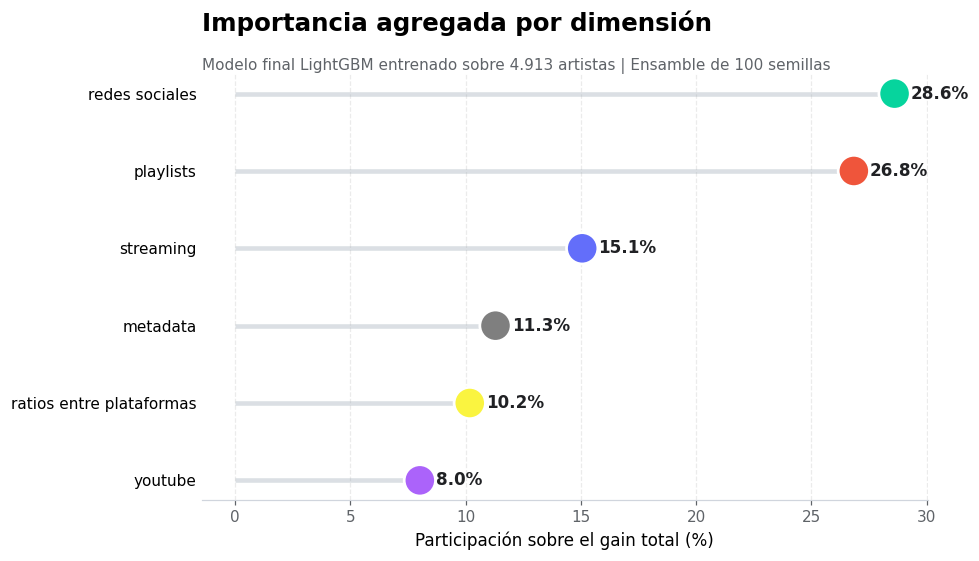

Guardado en: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos\lgbm-regression_lollipop_importancia_dimension.png


In [44]:
# ============================================================
# Lollipop de importancia agregada por dimensión
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

df_plot_dimension = (
    tabla_importancias_dimension
    .sort_values("gain_pct", ascending=True)
    .copy()
)

df_plot_dimension["gain_pct_100"] = df_plot_dimension["gain_pct"] * 100

# palette_dimension = {
#     "redes sociales": "#BD164F",
#     "playlists": "#1567A3",
#     "streaming": "#0C3E63",
#     "metadata": "#7D0E34",
#     "ratios entre plataformas": "#F4A261",
#     "youtube": "#2A9D8F",
# }

palette_dimension = {
    "streaming": "#636EFA",
    "playlists": "#EF553B",
    "redes sociales": "#06D49D",
    "youtube": "#AB63FA",
    "metadata": "#7F7F7F",
    "ratios entre plataformas": "#FAF440",
}

colors_dimension = [
    palette_dimension.get(dim, "#333333")
    for dim in df_plot_dimension["dimension"]
]

fig, ax = plt.subplots(figsize=(9, 5.2))

ax.hlines(
    y=df_plot_dimension["dimension"],
    xmin=0,
    xmax=df_plot_dimension["gain_pct_100"],
    linewidth=3,
    alpha=0.35,
    color="#9AA6B2"
)

ax.scatter(
    df_plot_dimension["gain_pct_100"],
    df_plot_dimension["dimension"],
    s=420,
    color=colors_dimension,
    edgecolor="white",
    linewidth=1.8,
    zorder=3
)

for y, valor in zip(df_plot_dimension["dimension"], df_plot_dimension["gain_pct_100"]):
    ax.text(
        valor + 0.7,
        y,
        f"{valor:.1f}%",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color="#202124"
    )

ax.set_title(
    "Importancia agregada por dimensión",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=28
)

ax.set_xlabel("Participación sobre el gain total (%)", fontsize=11)
ax.set_ylabel("")


ax.text(
    0,
    1.01,
    "Modelo final LightGBM entrenado sobre 4.913 artistas | Ensamble de 100 semillas",
    transform=ax.transAxes,
    fontsize=10,
    color="#5F6368"
)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#D0D5DD")
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors="#5F6368")

plt.tight_layout()

ruta_dimension = directorio_salidas_proyecto / f"{PARAM['experimento']}_lollipop_importancia_dimension.png"
plt.savefig(ruta_dimension, dpi=300, bbox_inches="tight")
plt.show()

print(f"Guardado en: {ruta_dimension}")

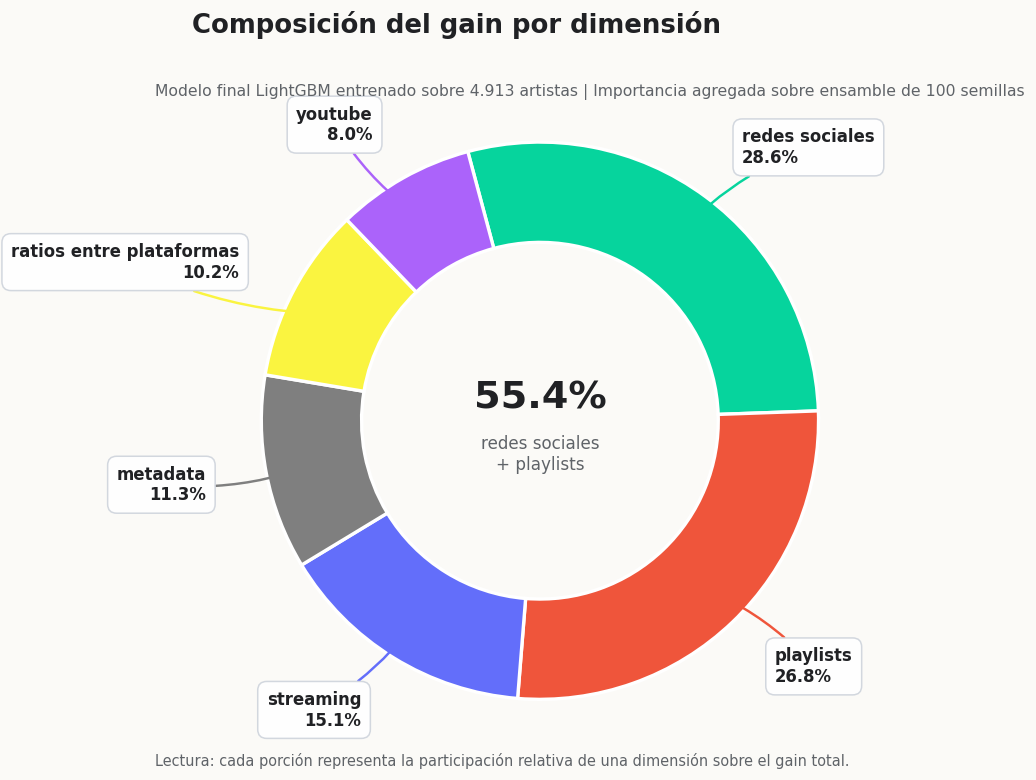

Guardado en: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos\lgbm-regression_donut_importancia_dimension.png


In [45]:
# ============================================================
# Donut editorial de importancia agregada por dimensión
# ============================================================

df_plot_dimension_donut = (
    tabla_importancias_dimension
    .sort_values("gain_pct", ascending=False)
    .copy()
)

df_plot_dimension_donut["gain_pct_100"] = (
    df_plot_dimension_donut["gain_pct"] * 100
)

# Normalización defensiva por posibles diferencias mínimas de redondeo
df_plot_dimension_donut["gain_pct_100_norm"] = (
    df_plot_dimension_donut["gain_pct_100"] /
    df_plot_dimension_donut["gain_pct_100"].sum() *
    100
)

palette_dimension = {
    "streaming": "#636EFA",
    "playlists": "#EF553B",
    "redes sociales": "#06D49D",
    "youtube": "#AB63FA",
    "metadata": "#7F7F7F",
    "ratios entre plataformas": "#FAF440",
}

colors_dimension = [
    palette_dimension.get(dimension, "#333333")
    for dimension in df_plot_dimension_donut["dimension"]
]

labels_dimension = df_plot_dimension_donut["dimension"].tolist()
values_dimension = df_plot_dimension_donut["gain_pct_100_norm"].values

gain_redes_playlists = (
    df_plot_dimension_donut
    .loc[
        df_plot_dimension_donut["dimension"].isin(["redes sociales", "playlists"]),
        "gain_pct_100_norm"
    ]
    .sum()
)

color_texto = "#202124"
color_secundario = "#5F6368"
color_fondo = "#FBFAF7"
color_borde = "#FFFFFF"

fig, ax = plt.subplots(figsize=(9.5, 7.2))
fig.patch.set_facecolor(color_fondo)
ax.set_facecolor(color_fondo)

wedges, _ = ax.pie(
    values_dimension,
    colors=colors_dimension,
    startangle=105,
    counterclock=False,
    wedgeprops=dict(
        width=0.36,
        edgecolor=color_borde,
        linewidth=2.2
    )
)

# ------------------------------------------------------------
# Centro del donut
# ------------------------------------------------------------

ax.text(
    0,
    0.08,
    f"{gain_redes_playlists:.1f}%",
    ha="center",
    va="center",
    fontsize=25,
    fontweight="bold",
    color=color_texto
)

ax.text(
    0,
    -0.12,
    "redes sociales\n+ playlists",
    ha="center",
    va="center",
    fontsize=11,
    color=color_secundario,
    linespacing=1.25
)

# ------------------------------------------------------------
# Etiquetas externas
# ------------------------------------------------------------

for wedge, dimension, valor, color_dimension in zip(
    wedges,
    labels_dimension,
    values_dimension,
    colors_dimension
):
    angulo = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.deg2rad(angulo))
    y = np.sin(np.deg2rad(angulo))

    radio_texto = 1.22
    x_texto = radio_texto * x
    y_texto = radio_texto * y

    alineacion_horizontal = "left" if x >= 0 else "right"

    ax.annotate(
        f"{dimension}\n{valor:.1f}%",
        xy=(0.82 * x, 0.82 * y),
        xytext=(x_texto, y_texto),
        ha=alineacion_horizontal,
        va="center",
        fontsize=10.8,
        fontweight="bold",
        color=color_texto,
        arrowprops=dict(
            arrowstyle="-",
            color=color_dimension,
            lw=1.6,
            shrinkA=0,
            shrinkB=0,
            connectionstyle="arc3,rad=0.12"
        ),
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor="white",
            edgecolor="#D0D5DD",
            alpha=0.95
        )
    )

    

# ------------------------------------------------------------
# Títulos
# ------------------------------------------------------------

titulo_grafico = "Composición del gain por dimensión"

subtitulo_grafico = (
    "Modelo final LightGBM entrenado sobre 4.913 artistas | "
    "Importancia agregada sobre ensamble de 100 semillas"
)

ax.set_title(
    titulo_grafico,
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=26,
    color=color_texto
)

ax.text(
    -1.38,
    1.18,
    subtitulo_grafico,
    fontsize=10.2,
    color=color_secundario,
    ha="left",
    va="center"
)

ax.text(
    -1.38,
    -1.22,
    "Lectura: cada porción representa la participación relativa de una dimensión sobre el gain total.",
    fontsize=9.5,
    color=color_secundario,
    ha="left",
    va="center"
)

ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()

ruta_dimension_donut = (
    directorio_salidas_proyecto /
    f"{PARAM['experimento']}_donut_importancia_dimension.png"
)

plt.savefig(
    ruta_dimension_donut,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print(f"Guardado en: {ruta_dimension_donut}")

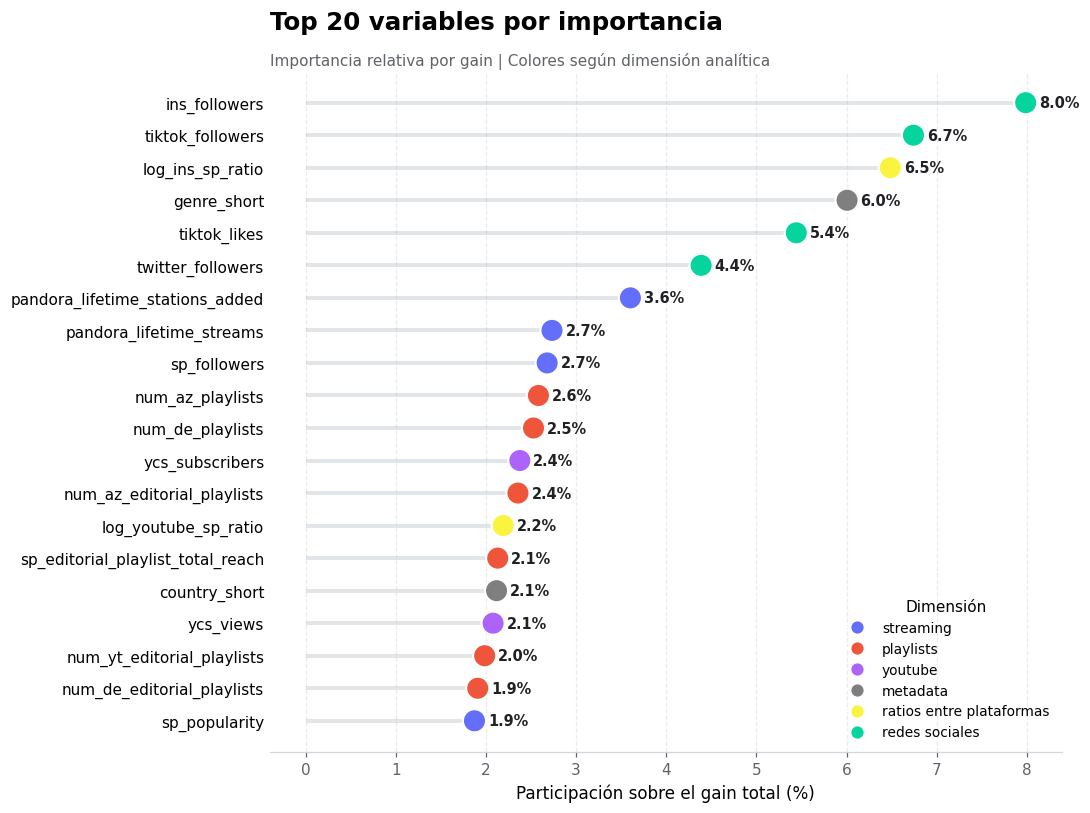

Guardado en: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos\lgbm-regression_lollipop_top_20_variables.png


In [46]:
# ============================================================
# Lollipop de top variables por gain
# ============================================================

top_n = 20

df_plot_top = (
    tabla_importancias_full
    .head(top_n)
    .sort_values("gain_pct", ascending=True)
    .copy()
)

df_plot_top["gain_pct_100"] = df_plot_top["gain_pct"] * 100

# palette_dimension = {
#     "redes sociales": "#BD164F",
#     "playlists": "#1567A3",
#     "streaming": "#0C3E63",
#     "metadata": "#7D0E34",
#     "ratios entre plataformas": "#F4A261",
#     "youtube": "#2A9D8F",
# }

palette_dimension = {
    "streaming": "#636EFA",
    "playlists": "#EF553B",
    "redes sociales": "#06D49D",
    "youtube": "#AB63FA",
    "metadata": "#7F7F7F",
    "ratios entre plataformas": "#FAF440",
}

colors_top = [
    palette_dimension.get(dim, "#333333")
    for dim in df_plot_top["dimension"]
]

fig, ax = plt.subplots(figsize=(10, 7.5))

ax.hlines(
    y=df_plot_top["variable"],
    xmin=0,
    xmax=df_plot_top["gain_pct_100"],
    linewidth=2.6,
    alpha=0.28,
    color="#9AA6B2"
)

ax.scatter(
    df_plot_top["gain_pct_100"],
    df_plot_top["variable"],
    s=230,
    color=colors_top,
    edgecolor="white",
    linewidth=1.4,
    zorder=3
)

for y, valor in zip(df_plot_top["variable"], df_plot_top["gain_pct_100"]):
    ax.text(
        valor + 0.15,
        y,
        f"{valor:.1f}%",
        va="center",
        ha="left",
        fontsize=9.5,
        fontweight="bold",
        color="#202124"
    )

ax.set_title(
    f"Top {top_n} variables por importancia",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=28
)

ax.text(
    0,
    1.01,
    "Importancia relativa por gain | Colores según dimensión analítica",
    transform=ax.transAxes,
    fontsize=10,
    color="#5F6368"
)

ax.set_xlabel("Participación sobre el gain total (%)", fontsize=11)
ax.set_ylabel("")

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#D0D5DD")
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors="#5F6368")

# Leyenda manual ordenada según presencia en el top
dimensiones_presentes = df_plot_top["dimension"].drop_duplicates().tolist()

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=dim,
        markerfacecolor=palette_dimension.get(dim, "#333333"),
        markeredgecolor="white",
        markersize=9
    )
    for dim in dimensiones_presentes
]

ax.legend(
    handles=handles,
    title="Dimensión",
    frameon=False,
    loc="lower right",
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()

ruta_top = directorio_salidas_proyecto / f"{PARAM['experimento']}_lollipop_top_{top_n}_variables.png"
plt.savefig(ruta_top, dpi=300, bbox_inches="tight")
plt.show()

print(f"Guardado en: {ruta_top}")

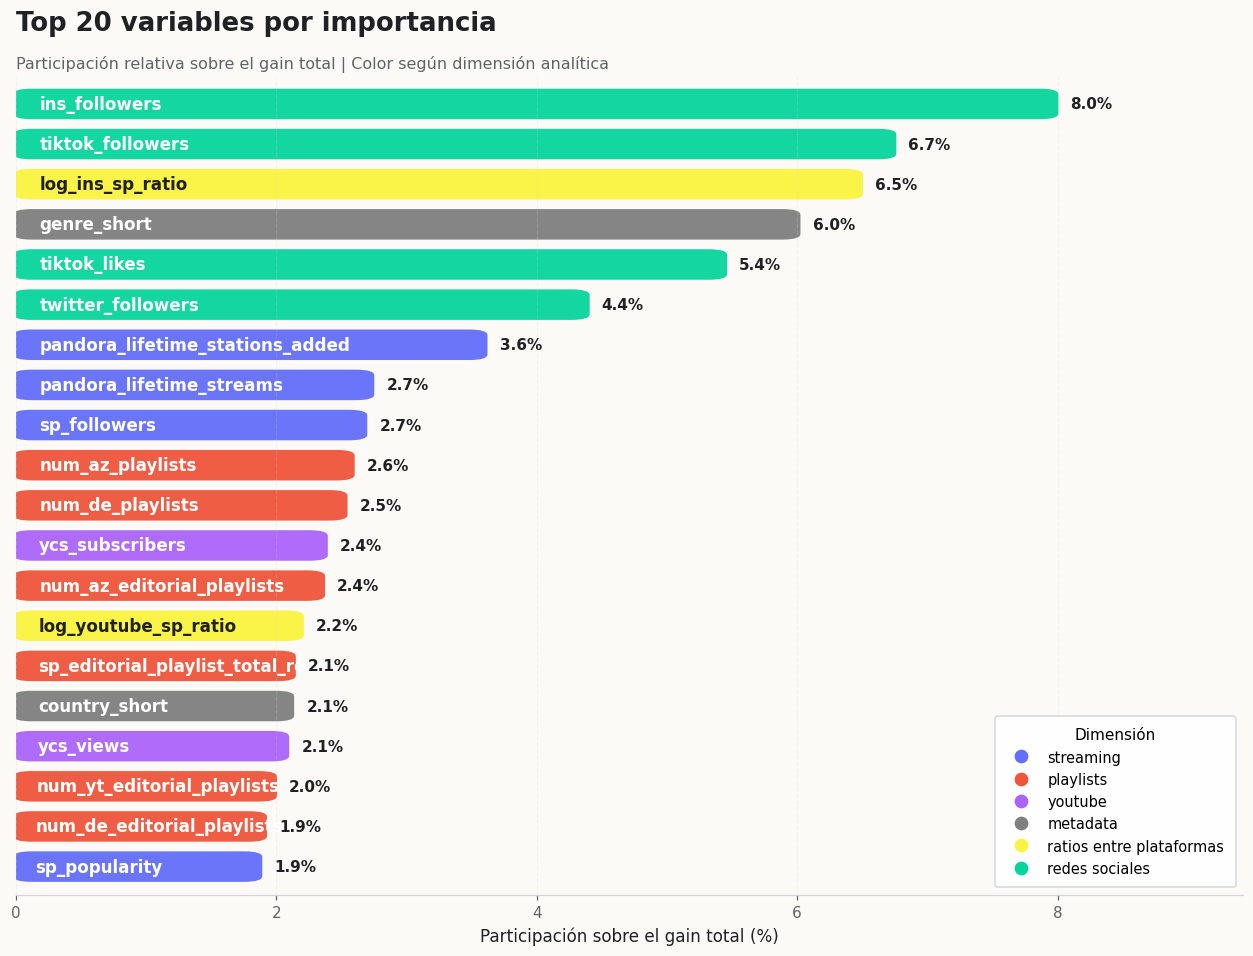

Guardado en: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos\lgbm-regression_top_20_variables_barras_redondeadas.png


In [47]:
# ============================================================
# Top variables por gain
# Barras horizontales redondeadas por dimensión
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D

top_n = 20

df_plot_top = (
    tabla_importancias_full
    .head(top_n)
    .sort_values("gain_pct", ascending=True)
    .copy()
)

df_plot_top["gain_pct_100"] = df_plot_top["gain_pct"] * 100

palette_dimension = {
    "streaming": "#636EFA",
    "playlists": "#EF553B",
    "redes sociales": "#06D49D",
    "youtube": "#AB63FA",
    "metadata": "#7F7F7F",
    "ratios entre plataformas": "#FAF440",
}

color_texto = "#202124"
color_secundario = "#5F6368"
color_grilla = "#D0D5DD"
color_fondo = "#FBFAF7"

def color_texto_interno(hex_color):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    luminancia = 0.299 * r + 0.587 * g + 0.114 * b
    return "#202124" if luminancia > 170 else "white"

fig, ax = plt.subplots(figsize=(11.5, 8.8))
fig.patch.set_facecolor(color_fondo)
ax.set_facecolor(color_fondo)

y_positions = np.arange(len(df_plot_top))
bar_height = 0.72

xmax = df_plot_top["gain_pct_100"].max() * 1.18
ax.set_xlim(0, xmax)
ax.set_ylim(-0.7, len(df_plot_top) - 0.3)

for i, (_, fila) in enumerate(df_plot_top.iterrows()):
    
    valor = fila["gain_pct_100"]
    variable = fila["variable"]
    dimension = fila["dimension"]
    color_barra = palette_dimension.get(dimension, "#333333")
    color_label = color_texto_interno(color_barra)

    # Barra redondeada
    barra = FancyBboxPatch(
        (0, i - bar_height / 2),
        valor,
        bar_height,
        boxstyle="round,pad=0.02,rounding_size=0.14",
        linewidth=0,
        facecolor=color_barra,
        edgecolor=color_barra,
        alpha=0.95
    )
    ax.add_patch(barra)

    # Nombre dentro de la barra
    x_texto_interno = min(0.18, valor * 0.08)
    x_texto_interno = max(x_texto_interno, 0.10)

    ax.text(
        x_texto_interno,
        i,
        variable,
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color=color_label
    )

    # Valor al final de la barra
    ax.text(
        valor + xmax * 0.012,
        i,
        f"{valor:.1f}%",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=color_texto
    )

# Títulos
ax.set_title(
    f"Top {top_n} variables por importancia",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=30,
    color=color_texto
)

ax.text(
    0,
    1.01,
    "Participación relativa sobre el gain total | Color según dimensión analítica",
    transform=ax.transAxes,
    fontsize=10.5,
    color=color_secundario
)

ax.set_xlabel("Participación sobre el gain total (%)", fontsize=11, color=color_texto)
ax.set_ylabel("")

# Ejes y grilla
ax.set_yticks(y_positions)
ax.set_yticklabels([""] * len(y_positions))

ax.grid(axis="x", linestyle="--", alpha=0.22, color=color_grilla)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(color_grilla)

ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors=color_secundario)

# Leyenda manual
dimensiones_presentes = df_plot_top["dimension"].drop_duplicates().tolist()

handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=dim,
        markerfacecolor=palette_dimension.get(dim, "#333333"),
        markeredgecolor="white",
        markersize=10
    )
    for dim in dimensiones_presentes
]

legend = ax.legend(
    handles=handles,
    title="Dimensión",
    frameon=True,
    fancybox=True,
    loc="lower right",
    fontsize=9.5,
    title_fontsize=10,
    borderpad=0.8
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#D0D5DD")
legend.get_frame().set_alpha(0.95)

plt.tight_layout()

ruta_top = (
    directorio_salidas_proyecto /
    f"{PARAM['experimento']}_top_{top_n}_variables_barras_redondeadas.png"
)

plt.savefig(
    ruta_top,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print(f"Guardado en: {ruta_top}")

# DIAGNOSTICO 
Relación con el target: qué puede decir el modelo

Predicho vs observado en holdout, en escala log.

Distribución de residuos.

Error por niveles de actividad live: ceros, baja, media, alta.

Cobertura de predicción si guardamos las predicciones de cada corrida/semilla: ver si el ensamble es estable por artista.

## predicho vs observado

In [48]:
# ============================================================
# Diagnóstico de predicción sobre holdout
# Grupos definidos con la misma lógica de estratificación
# ============================================================

df_pred_holdout = pd.DataFrame({
    "y_obs_log": y_holdout,
    "y_pred_log": y_pred_mean,
})

df_pred_holdout["residuo_log"] = (
    df_pred_holdout["y_obs_log"] - df_pred_holdout["y_pred_log"]
)

df_pred_holdout["error_abs_log"] = df_pred_holdout["residuo_log"].abs()

df_pred_holdout["y_obs_original"] = np.expm1(df_pred_holdout["y_obs_log"])
df_pred_holdout["y_pred_original"] = np.expm1(df_pred_holdout["y_pred_log"])

df_pred_holdout["error_abs_original"] = (
    df_pred_holdout["y_obs_original"] - df_pred_holdout["y_pred_original"]
).abs()

# Cortes por cuantiles definidos sobre todo el target disponible,
# igual que en la estrategia de estratificación.
_, bins_target_log = pd.qcut(
    pd.Series(y_all),
    q=5,
    retbins=True,
    duplicates="drop"
)

# Se amplían extremos para asegurar que todo holdout entre en algún grupo.
bins_target_log[0] = -np.inf
bins_target_log[-1] = np.inf

n_grupos_target = len(bins_target_log) - 1

labels_grupos_target = [
    f"Q{i+1}" for i in range(n_grupos_target)
]

df_pred_holdout["grupo_target_log"] = pd.cut(
    df_pred_holdout["y_obs_log"],
    bins=bins_target_log,
    labels=labels_grupos_target,
    include_lowest=True
)

display(df_pred_holdout.describe())

,y_obs_log,y_pred_log,residuo_log,error_abs_log,y_obs_original,y_pred_original,error_abs_original
count,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000,1474.000000
mean,2.322284,2.310478,0.011805,0.993636,24.558345,13.627716,17.023197
std,1.547527,0.901818,1.234731,0.732609,30.009949,13.391169,21.627274
min,0.000000,-0.151211,-3.801442,0.005371,0.000000,-0.140334,0.010989
25%,0.693147,1.720845,-0.828031,0.406445,1.000000,4.589248,2.897293
50%,2.564949,2.366551,0.127876,0.866652,12.000000,9.660560,8.333776
75%,3.688879,2.957574,0.903733,1.423459,39.000000,18.251223,23.143457
max,5.192957,4.573404,3.873976,3.873976,179.000000,95.873299,164.654788


In [49]:
# ============================================================
# Error por grupos del target definidos por cuantiles
# ============================================================

tabla_error_por_grupo_target = (
    df_pred_holdout
    .groupby("grupo_target_log", observed=True)
    .agg(
        n_artistas=("y_obs_log", "size"),
        y_obs_log_media=("y_obs_log", "mean"),
        y_obs_log_mediana=("y_obs_log", "median"),
        y_pred_log_media=("y_pred_log", "mean"),
        y_pred_log_mediana=("y_pred_log", "median"),
        residuo_log_medio=("residuo_log", "mean"),
        mae_log=("error_abs_log", "mean"),
        rmse_log=("residuo_log", lambda x: np.sqrt(np.mean(x ** 2))),
        shows_obs_mediana=("y_obs_original", "median"),
        shows_pred_mediana=("y_pred_original", "median"),
        mae_original=("error_abs_original", "mean"),
    )
    .reset_index()
)

tabla_error_por_grupo_target["sesgo_interpretacion"] = np.where(
    tabla_error_por_grupo_target["residuo_log_medio"] > 0,
    "subpredice",
    np.where(
        tabla_error_por_grupo_target["residuo_log_medio"] < 0,
        "sobrepredice",
        "sin sesgo medio"
    )
)

display(tabla_error_por_grupo_target)

tabla_error_por_grupo_target.to_csv(
    f"{PARAM['experimento']}_error_por_quintil_target_holdout.csv",
    index=False
)

,grupo_target_log,n_artistas,y_obs_log_media,y_obs_log_mediana,y_pred_log_media,y_pred_log_mediana,residuo_log_medio,mae_log,rmse_log,shows_obs_mediana,shows_pred_mediana,mae_original,sesgo_interpretacion
0,Q1,378,0.221880,0.000000,1.574603,1.529884,-1.352723,1.364907,1.613539,0.0,3.617704,5.726845,sobrepredice
1,Q2,225,1.442821,1.386294,2.115268,2.134926,-0.672447,0.803563,0.998521,3.0,7.456418,6.634507,sobrepredice
2,Q3,293,2.587131,2.639057,2.264859,2.339337,0.322272,0.576333,0.724081,13.0,9.374352,6.537999,subpredice
3,Q4,290,3.511299,3.496508,2.703956,2.763259,0.807343,0.848563,1.017523,32.0,14.851699,18.048628,subpredice
4,Q5,288,4.299425,4.283563,3.079022,3.138589,1.220402,1.225467,1.423454,71.5,22.071433,49.600503,subpredice


In [50]:
# ============================================================
# Diagnóstico de predicción sobre holdout
# ============================================================

df_pred_holdout = pd.DataFrame({
    "y_obs_log": y_holdout,
    "y_pred_log": y_pred_mean,
})

df_pred_holdout["residuo_log"] = (
    df_pred_holdout["y_obs_log"] - df_pred_holdout["y_pred_log"]
)

df_pred_holdout["error_abs_log"] = df_pred_holdout["residuo_log"].abs()

df_pred_holdout["y_obs_original"] = np.expm1(df_pred_holdout["y_obs_log"])
df_pred_holdout["y_pred_original"] = np.expm1(df_pred_holdout["y_pred_log"])

df_pred_holdout["error_abs_original"] = (
    df_pred_holdout["y_obs_original"] - df_pred_holdout["y_pred_original"]
).abs()

_, bins_target_log = pd.qcut(
    pd.Series(y_all),
    q=5,
    retbins=True,
    duplicates="drop"
)

bins_target_log[0] = -np.inf
bins_target_log[-1] = np.inf

labels_grupos_target = [
    f"Q{i+1}" for i in range(len(bins_target_log) - 1)
]

df_pred_holdout["grupo_target_log"] = pd.cut(
    df_pred_holdout["y_obs_log"],
    bins=bins_target_log,
    labels=labels_grupos_target,
    include_lowest=True
)

tabla_error_por_quintil = (
    df_pred_holdout
    .groupby("grupo_target_log", observed=True)
    .agg(
        n_artistas=("y_obs_log", "size"),
        n_cero_shows=("y_obs_original", lambda x: int((x == 0).sum())),
        shows_obs_mediana=("y_obs_original", "median"),
        shows_pred_mediana=("y_pred_original", "median"),
        y_obs_log_media=("y_obs_log", "mean"),
        y_pred_log_media=("y_pred_log", "mean"),
        residuo_log_medio=("residuo_log", "mean"),
        mae_log=("error_abs_log", "mean"),
        rmse_log=("residuo_log", lambda x: np.sqrt(np.mean(x ** 2))),
        mae_original=("error_abs_original", "mean"),
    )
    .reset_index()
)

tabla_error_por_quintil["pct_cero_shows"] = (
    tabla_error_por_quintil["n_cero_shows"] /
    tabla_error_por_quintil["n_artistas"] *
    100
)

display(tabla_error_por_quintil)

,grupo_target_log,n_artistas,n_cero_shows,shows_obs_mediana,shows_pred_mediana,y_obs_log_media,y_pred_log_media,residuo_log_medio,mae_log,rmse_log,mae_original,pct_cero_shows
0,Q1,378,257,0.0,3.617704,0.221880,1.574603,-1.352723,1.364907,1.613539,5.726845,67.989418
1,Q2,225,0,3.0,7.456418,1.442821,2.115268,-0.672447,0.803563,0.998521,6.634507,0.000000
2,Q3,293,0,13.0,9.374352,2.587131,2.264859,0.322272,0.576333,0.724081,6.537999,0.000000
3,Q4,290,0,32.0,14.851699,3.511299,2.703956,0.807343,0.848563,1.017523,18.048628,0.000000
4,Q5,288,0,71.5,22.071433,4.299425,3.079022,1.220402,1.225467,1.423454,49.600503,0.000000


In [51]:
# ============================================================
# Diagnóstico específico: artistas con cero shows vs resto
# ============================================================

df_pred_holdout["grupo_cero_shows"] = np.where(
    df_pred_holdout["y_obs_original"] == 0,
    "0 shows",
    "más de 0 shows"
)

tabla_error_ceros = (
    df_pred_holdout
    .groupby("grupo_cero_shows", observed=True)
    .agg(
        n_artistas=("y_obs_original", "size"),
        shows_obs_mediana=("y_obs_original", "median"),
        shows_pred_mediana=("y_pred_original", "median"),
        pred_log_media=("y_pred_log", "mean"),
        pred_original_media=("y_pred_original", "mean"),
        residuo_log_medio=("residuo_log", "mean"),
        mae_log=("error_abs_log", "mean"),
        rmse_log=("residuo_log", lambda x: np.sqrt(np.mean(x ** 2))),
        mae_original=("error_abs_original", "mean"),
    )
    .reset_index()
)

display(tabla_error_ceros)

,grupo_cero_shows,n_artistas,shows_obs_mediana,shows_pred_mediana,pred_log_media,pred_original_media,residuo_log_medio,mae_log,rmse_log,mae_original
0,0 shows,257,0.0,2.834789,1.492679,5.937309,-1.492679,1.497034,1.756249,5.941456
1,más de 0 shows,1217,19.0,11.031691,2.483177,15.251738,0.329515,0.887331,1.092738,19.363383


## grafico obs s predicho original

Gráficos guardados en: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos_lgbm-regression


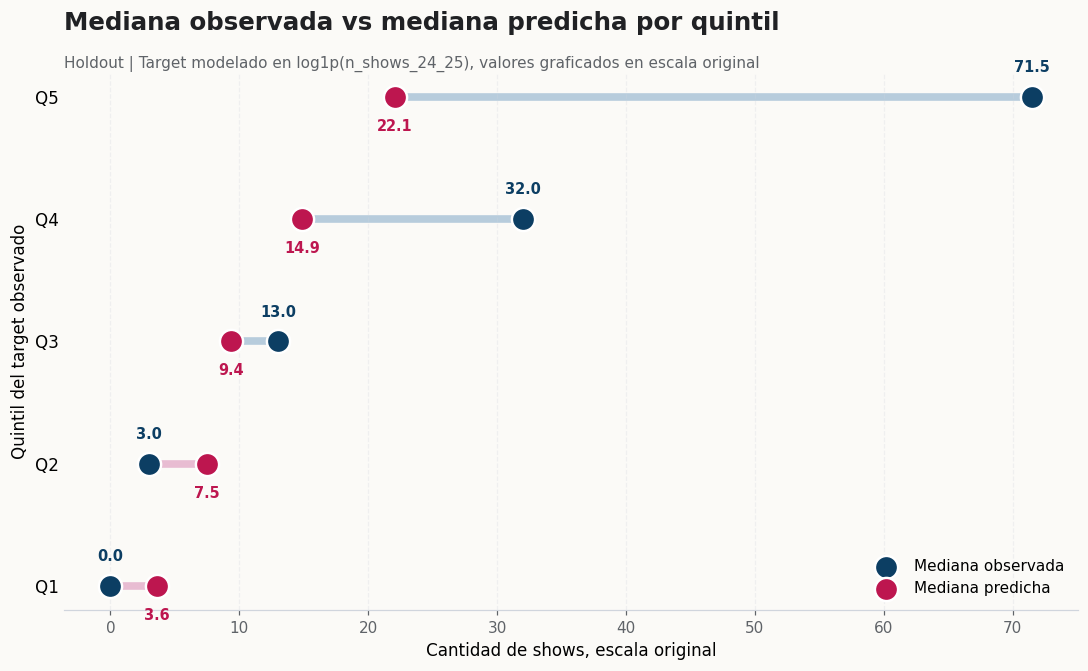

Guardado en: graficos_lgbm-regression\lgbm-regression_mediana_observada_vs_predicha_por_quintil.png


In [52]:
# ============================================================
# Mediana observada vs mediana predicha por quintil del target
# ============================================================

import pathlib
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Directorio de guardado
# ------------------------------------------------------------

if "graficos_dir" not in globals():
    graficos_dir = pathlib.Path(f"graficos_{PARAM['experimento']}")
    graficos_dir.mkdir(exist_ok=True)

print(f"Gráficos guardados en: {graficos_dir.resolve()}")

# ------------------------------------------------------------
# Preparación de datos
# ------------------------------------------------------------

df_plot_medianas_quintil = tabla_error_por_quintil.copy()

df_plot_medianas_quintil["brecha_mediana"] = (
    df_plot_medianas_quintil["shows_pred_mediana"] -
    df_plot_medianas_quintil["shows_obs_mediana"]
)

df_plot_medianas_quintil["direccion_sesgo"] = np.where(
    df_plot_medianas_quintil["brecha_mediana"] > 0,
    "sobrepredicción",
    np.where(
        df_plot_medianas_quintil["brecha_mediana"] < 0,
        "subpredicción",
        "sin brecha"
    )
)

# Orden natural de los quintiles
df_plot_medianas_quintil = df_plot_medianas_quintil.sort_values(
    "grupo_target_log"
).reset_index(drop=True)

posiciones_y = np.arange(len(df_plot_medianas_quintil))

# ------------------------------------------------------------
# Paleta
# ------------------------------------------------------------

color_observado = "#0C3E63"
color_predicho = "#BD164F"
color_linea_sobre = "#D989B5"
color_linea_sub = "#7FA7C7"
color_texto = "#202124"
color_grilla = "#D0D5DD"
color_fondo = "#FBFAF7"

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6.2))
fig.patch.set_facecolor(color_fondo)
ax.set_facecolor(color_fondo)

for i, fila in df_plot_medianas_quintil.iterrows():
    
    x_obs = fila["shows_obs_mediana"]
    x_pred = fila["shows_pred_mediana"]
    
    color_linea = (
        color_linea_sobre
        if fila["brecha_mediana"] > 0
        else color_linea_sub
    )
    
    ax.plot(
        [x_obs, x_pred],
        [posiciones_y[i], posiciones_y[i]],
        color=color_linea,
        linewidth=5,
        alpha=0.55,
        solid_capstyle="round",
        zorder=1
    )
    
    ax.scatter(
        x_obs,
        posiciones_y[i],
        s=230,
        color=color_observado,
        edgecolor="white",
        linewidth=1.6,
        zorder=3,
        label="Mediana observada" if i == 0 else None
    )
    
    ax.scatter(
        x_pred,
        posiciones_y[i],
        s=230,
        color=color_predicho,
        edgecolor="white",
        linewidth=1.6,
        zorder=3,
        label="Mediana predicha" if i == 0 else None
    )
    
    ax.text(
        x_obs,
        posiciones_y[i] + 0.18,
        f"{x_obs:.1f}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        color=color_observado,
        fontweight="bold"
    )
    
    ax.text(
        x_pred,
        posiciones_y[i] - 0.18,
        f"{x_pred:.1f}",
        ha="center",
        va="top",
        fontsize=9.5,
        color=color_predicho,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Detalles visuales
# ------------------------------------------------------------

ax.set_yticks(posiciones_y)
ax.set_yticklabels(df_plot_medianas_quintil["grupo_target_log"], fontsize=11)

ax.set_xlabel("Cantidad de shows, escala original", fontsize=11)
ax.set_ylabel("Quintil del target observado", fontsize=11)

ax.set_title(
    "Mediana observada vs mediana predicha por quintil",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=28,
    color=color_texto
)

ax.text(
    0,
    1.01,
    "Holdout | Target modelado en log1p(n_shows_24_25), valores graficados en escala original",
    transform=ax.transAxes,
    fontsize=10,
    color="#5F6368"
)

ax.grid(axis="x", linestyle="--", alpha=0.28, color=color_grilla)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(color_grilla)

ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors="#5F6368")

ax.legend(
    frameon=False,
    loc="lower right",
    fontsize=10
)

plt.tight_layout()

ruta_grafico_medianas_quintil = (
    graficos_dir /
    f"{PARAM['experimento']}_mediana_observada_vs_predicha_por_quintil.png"
)

plt.savefig(
    ruta_grafico_medianas_quintil,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print(f"Guardado en: {ruta_grafico_medianas_quintil}")

## grafico obs vs predichos log

In [53]:
# ============================================================
# Mediana observada vs mediana predicha por quintil
# Escala log1p(n_shows_24_25)
# ============================================================

import pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Directorio de guardado
# ------------------------------------------------------------

if "graficos_dir" not in globals():
    graficos_dir = pathlib.Path(f"graficos_{PARAM['experimento']}")
    graficos_dir.mkdir(exist_ok=True)

print(f"Gráficos guardados en: {graficos_dir.resolve()}")

# ------------------------------------------------------------
# Preparación de datos en escala log
# ------------------------------------------------------------

df_plot_medianas_log_quintil = (
    df_pred_holdout
    .groupby("grupo_target_log", observed=True)
    .agg(
        n_artistas=("y_obs_log", "size"),
        y_obs_log_mediana=("y_obs_log", "median"),
        y_pred_log_mediana=("y_pred_log", "median"),
        shows_obs_mediana=("y_obs_original", "median"),
        shows_pred_mediana=("y_pred_original", "median"),
    )
    .reset_index()
)

df_plot_medianas_log_quintil["brecha_log_mediana"] = (
    df_plot_medianas_log_quintil["y_pred_log_mediana"] -
    df_plot_medianas_log_quintil["y_obs_log_mediana"]
)

df_plot_medianas_log_quintil["direccion_sesgo"] = np.where(
    df_plot_medianas_log_quintil["brecha_log_mediana"] > 0,
    "sobrepredicción",
    np.where(
        df_plot_medianas_log_quintil["brecha_log_mediana"] < 0,
        "subpredicción",
        "sin brecha"
    )
)

df_plot_medianas_log_quintil = df_plot_medianas_log_quintil.sort_values(
    "grupo_target_log"
).reset_index(drop=True)

posiciones_y = np.arange(len(df_plot_medianas_log_quintil))

display(df_plot_medianas_log_quintil)

Gráficos guardados en: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos_lgbm-regression


,grupo_target_log,n_artistas,y_obs_log_mediana,y_pred_log_mediana,shows_obs_mediana,shows_pred_mediana,brecha_log_mediana,direccion_sesgo
0,Q1,378,0.000000,1.529884,0.0,3.617704,1.529884,sobrepredicción
1,Q2,225,1.386294,2.134926,3.0,7.456418,0.748631,sobrepredicción
2,Q3,293,2.639057,2.339337,13.0,9.374352,-0.299721,subpredicción
3,Q4,290,3.496508,2.763259,32.0,14.851699,-0.733249,subpredicción
4,Q5,288,4.283563,3.138589,71.5,22.071433,-1.144974,subpredicción


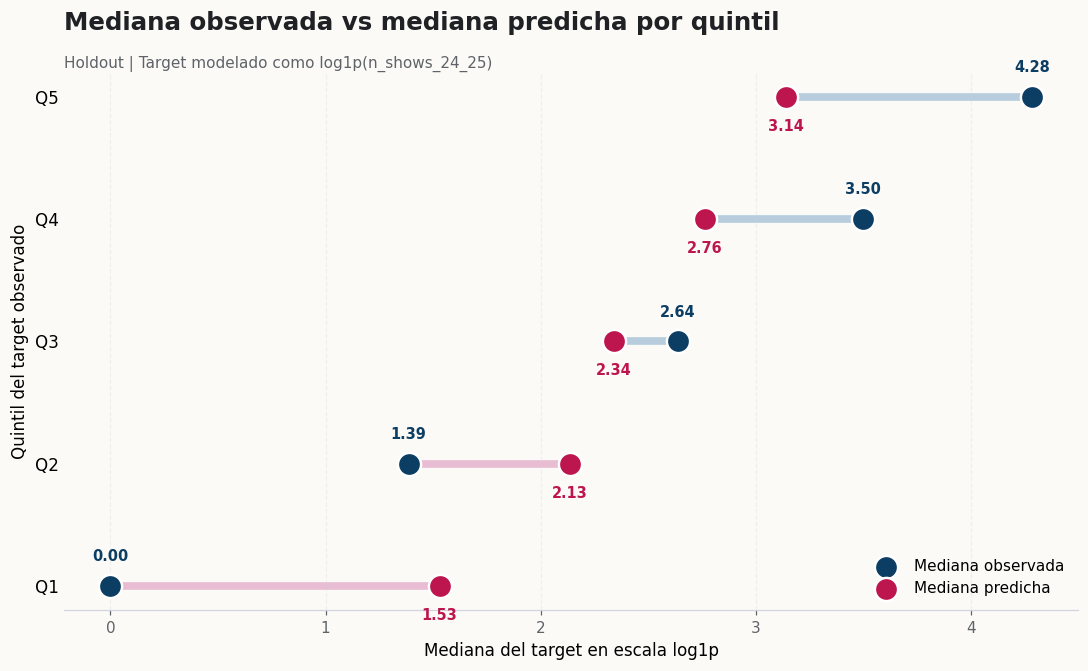

Guardado en: graficos_lgbm-regression\lgbm-regression_mediana_observada_vs_predicha_por_quintil_log.png


In [54]:
# ============================================================
# Dumbbell plot en escala log1p
# ============================================================

color_observado = "#0C3E63"
color_predicho = "#BD164F"
color_linea_sobre = "#D989B5"
color_linea_sub = "#7FA7C7"
color_texto = "#202124"
color_grilla = "#D0D5DD"
color_fondo = "#FBFAF7"

fig, ax = plt.subplots(figsize=(10, 6.2))
fig.patch.set_facecolor(color_fondo)
ax.set_facecolor(color_fondo)

for i, fila in df_plot_medianas_log_quintil.iterrows():
    
    x_obs = fila["y_obs_log_mediana"]
    x_pred = fila["y_pred_log_mediana"]
    
    color_linea = (
        color_linea_sobre
        if fila["brecha_log_mediana"] > 0
        else color_linea_sub
    )
    
    ax.plot(
        [x_obs, x_pred],
        [posiciones_y[i], posiciones_y[i]],
        color=color_linea,
        linewidth=5,
        alpha=0.55,
        solid_capstyle="round",
        zorder=1
    )
    
    ax.scatter(
        x_obs,
        posiciones_y[i],
        s=230,
        color=color_observado,
        edgecolor="white",
        linewidth=1.6,
        zorder=3,
        label="Mediana observada" if i == 0 else None
    )
    
    ax.scatter(
        x_pred,
        posiciones_y[i],
        s=230,
        color=color_predicho,
        edgecolor="white",
        linewidth=1.6,
        zorder=3,
        label="Mediana predicha" if i == 0 else None
    )
    
    ax.text(
        x_obs,
        posiciones_y[i] + 0.18,
        f"{x_obs:.2f}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        color=color_observado,
        fontweight="bold"
    )
    
    ax.text(
        x_pred,
        posiciones_y[i] - 0.18,
        f"{x_pred:.2f}",
        ha="center",
        va="top",
        fontsize=9.5,
        color=color_predicho,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Detalles visuales
# ------------------------------------------------------------

ax.set_yticks(posiciones_y)
ax.set_yticklabels(
    df_plot_medianas_log_quintil["grupo_target_log"],
    fontsize=11
)

ax.set_xlabel("Mediana del target en escala log1p", fontsize=11)
ax.set_ylabel("Quintil del target observado", fontsize=11)

ax.set_title(
    "Mediana observada vs mediana predicha por quintil",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=28,
    color=color_texto
)

ax.text(
    0,
    1.01,
    "Holdout | Target modelado como log1p(n_shows_24_25)",
    transform=ax.transAxes,
    fontsize=10,
    color="#5F6368"
)

ax.grid(axis="x", linestyle="--", alpha=0.28, color=color_grilla)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(color_grilla)

ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors="#5F6368")

ax.legend(
    frameon=False,
    loc="lower right",
    fontsize=10
)

plt.tight_layout()

ruta_grafico_medianas_log_quintil = (
    graficos_dir /
    f"{PARAM['experimento']}_mediana_observada_vs_predicha_por_quintil_log.png"
)

plt.savefig(
    ruta_grafico_medianas_log_quintil,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print(f"Guardado en: {ruta_grafico_medianas_log_quintil}")

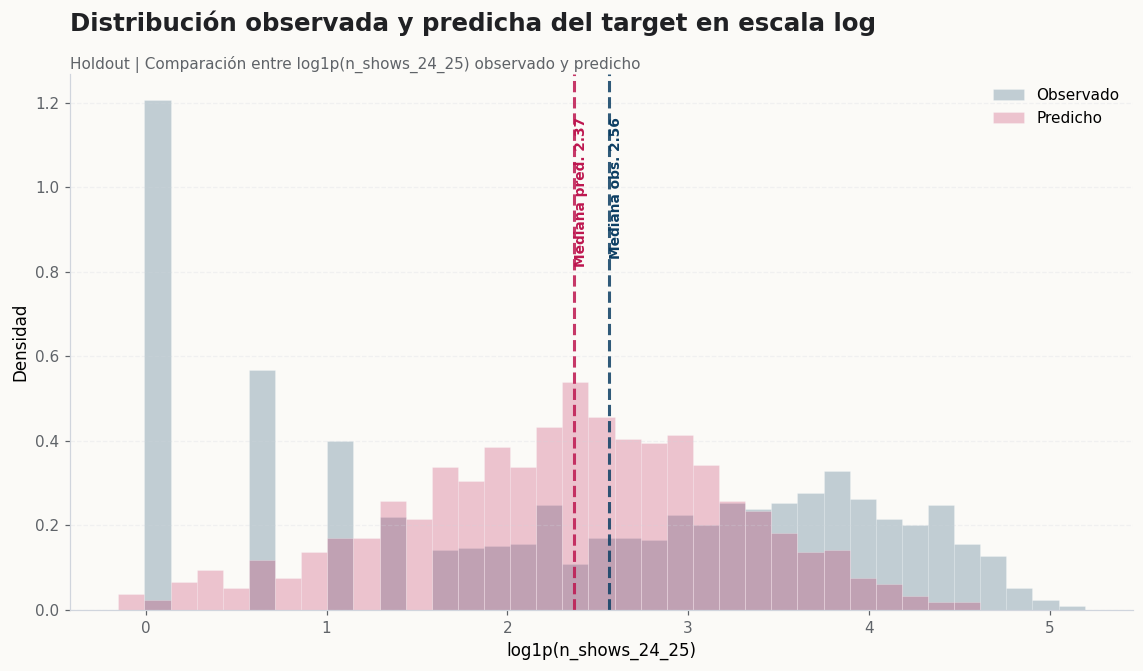

Guardado en: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos\lgbm-regression_distribucion_observada_predicha_log.png


In [55]:
# ============================================================
# Distribución observada y predicha del target en escala log
# ============================================================

import pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if "graficos_dir" not in globals():
    graficos_dir = pathlib.Path(f"graficos_{PARAM['experimento']}")
    graficos_dir.mkdir(exist_ok=True)

color_observado = "#0C3E63"
color_predicho = "#BD164F"
color_texto = "#202124"
color_secundario = "#5F6368"
color_grilla = "#D0D5DD"
color_fondo = "#FBFAF7"

y_obs_log_plot = df_pred_holdout["y_obs_log"].dropna()
y_pred_log_plot = df_pred_holdout["y_pred_log"].dropna()

mediana_obs_log = y_obs_log_plot.median()
mediana_pred_log = y_pred_log_plot.median()

bins_log = np.linspace(
    min(y_obs_log_plot.min(), y_pred_log_plot.min()),
    max(y_obs_log_plot.max(), y_pred_log_plot.max()),
    38
)

fig, ax = plt.subplots(figsize=(10.5, 6.2))
fig.patch.set_facecolor(color_fondo)
ax.set_facecolor(color_fondo)

ax.hist(
    y_obs_log_plot,
    bins=bins_log,
    density=True,
    alpha=0.24,
    color=color_observado,
    edgecolor="white",
    linewidth=0.6,
    label="Observado"
)

ax.hist(
    y_pred_log_plot,
    bins=bins_log,
    density=True,
    alpha=0.24,
    color=color_predicho,
    edgecolor="white",
    linewidth=0.6,
    label="Predicho"
)

# y_obs_log_plot.plot(
#     kind="kde",
#     ax=ax,
#     color=color_observado,
#     linewidth=3.2
# )

# y_pred_log_plot.plot(
#     kind="kde",
#     ax=ax,
#     color=color_predicho,
#     linewidth=3.2
# )

ax.axvline(
    mediana_obs_log,
    color=color_observado,
    linestyle="--",
    linewidth=2,
    alpha=0.85
)

ax.axvline(
    mediana_pred_log,
    color=color_predicho,
    linestyle="--",
    linewidth=2,
    alpha=0.85
)

altura_texto = ax.get_ylim()[1] * 0.92

ax.text(
    mediana_obs_log,
    altura_texto,
    f"Mediana obs. {mediana_obs_log:.2f}",
    rotation=90,
    va="top",
    ha="left",
    fontsize=9,
    color=color_observado,
    fontweight="bold"
)

ax.text(
    mediana_pred_log,
    altura_texto,
    f"Mediana pred. {mediana_pred_log:.2f}",
    rotation=90,
    va="top",
    ha="left",
    fontsize=9,
    color=color_predicho,
    fontweight="bold"
)

titulo_grafico = "Distribución observada y predicha del target en escala log"
subtitulo_grafico = "Holdout | Comparación entre log1p(n_shows_24_25) observado y predicho"

ax.set_title(
    titulo_grafico,
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=28,
    color=color_texto
)

ax.text(
    0,
    1.01,
    subtitulo_grafico,
    transform=ax.transAxes,
    fontsize=10,
    color=color_secundario
)

ax.set_xlabel("log1p(n_shows_24_25)", fontsize=11)
ax.set_ylabel("Densidad", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.25, color=color_grilla)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(color_grilla)
ax.spines["bottom"].set_color(color_grilla)

ax.tick_params(axis="x", colors=color_secundario)
ax.tick_params(axis="y", colors=color_secundario)

ax.legend(
    frameon=False,
    loc="upper right",
    fontsize=10
)

plt.tight_layout()

ruta_distribuciones_log = (
    directorio_salidas_proyecto /
    f"{PARAM['experimento']}_distribucion_observada_predicha_log.png"
)

plt.savefig(
    ruta_distribuciones_log,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print(f"Guardado en: {ruta_distribuciones_log}")

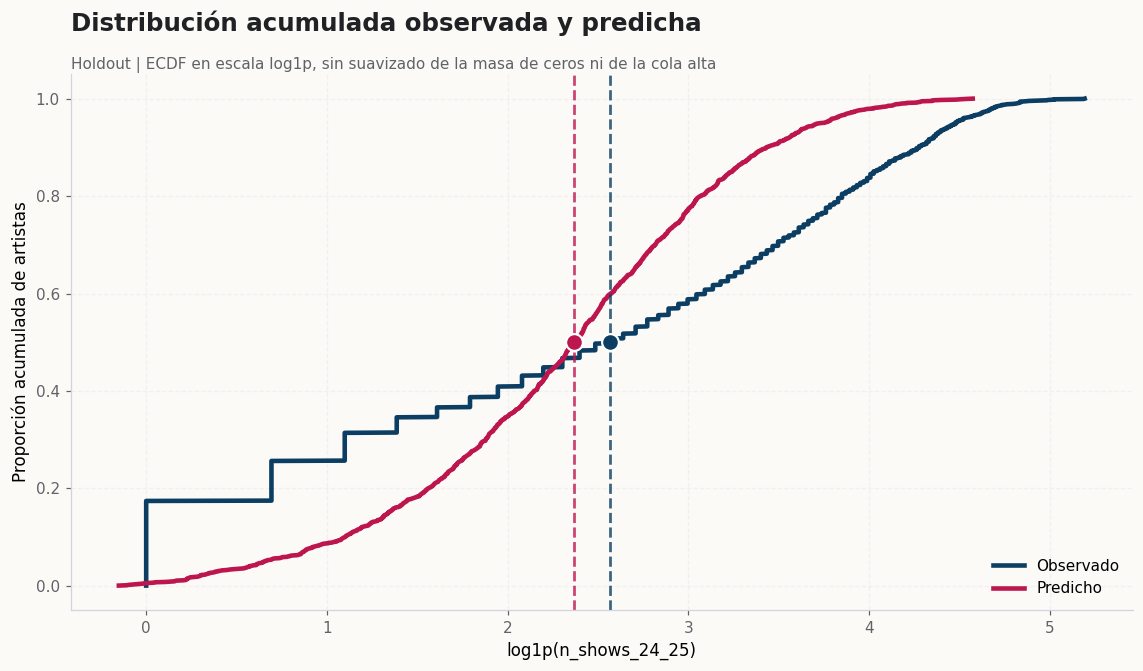

Guardado en: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos\lgbm-regression_ecdf_observada_predicha_log.png


In [56]:
# ============================================================
# ECDF observada y predicha del target en escala log
# ============================================================

def calcular_ecdf(valores):
    valores_ordenados = np.sort(np.asarray(valores))
    proporcion_acumulada = np.arange(1, len(valores_ordenados) + 1) / len(valores_ordenados)
    return valores_ordenados, proporcion_acumulada

x_obs_ecdf, y_obs_ecdf = calcular_ecdf(y_obs_log_plot)
x_pred_ecdf, y_pred_ecdf = calcular_ecdf(y_pred_log_plot)

fig, ax = plt.subplots(figsize=(10.5, 6.2))
fig.patch.set_facecolor(color_fondo)
ax.set_facecolor(color_fondo)

ax.plot(
    x_obs_ecdf,
    y_obs_ecdf,
    color=color_observado,
    linewidth=3,
    label="Observado"
)

ax.plot(
    x_pred_ecdf,
    y_pred_ecdf,
    color=color_predicho,
    linewidth=3,
    label="Predicho"
)

ax.axvline(
    mediana_obs_log,
    color=color_observado,
    linestyle="--",
    linewidth=1.8,
    alpha=0.8
)

ax.axvline(
    mediana_pred_log,
    color=color_predicho,
    linestyle="--",
    linewidth=1.8,
    alpha=0.8
)

ax.scatter(
    [mediana_obs_log],
    [0.5],
    s=120,
    color=color_observado,
    edgecolor="white",
    linewidth=1.4,
    zorder=4
)

ax.scatter(
    [mediana_pred_log],
    [0.5],
    s=120,
    color=color_predicho,
    edgecolor="white",
    linewidth=1.4,
    zorder=4
)

titulo_grafico = "Distribución acumulada observada y predicha"
subtitulo_grafico = "Holdout | ECDF en escala log1p, sin suavizado de la masa de ceros ni de la cola alta"

ax.set_title(
    titulo_grafico,
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=28,
    color=color_texto
)

ax.text(
    0,
    1.01,
    subtitulo_grafico,
    transform=ax.transAxes,
    fontsize=10,
    color=color_secundario
)

ax.set_xlabel("log1p(n_shows_24_25)", fontsize=11)
ax.set_ylabel("Proporción acumulada de artistas", fontsize=11)

ax.grid(axis="both", linestyle="--", alpha=0.25, color=color_grilla)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(color_grilla)
ax.spines["bottom"].set_color(color_grilla)

ax.tick_params(axis="x", colors=color_secundario)
ax.tick_params(axis="y", colors=color_secundario)

ax.legend(
    frameon=False,
    loc="lower right",
    fontsize=10
)

plt.tight_layout()

ruta_ecdf_log = (
    directorio_salidas_proyecto /
    f"{PARAM['experimento']}_ecdf_observada_predicha_log.png"
)

plt.savefig(
    ruta_ecdf_log,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print(f"Guardado en: {ruta_ecdf_log}")

In [57]:
resumen_holdout.to_csv(
    "lgbm_regression_resumen_holdout.csv",
    index=False
)

tabla_error_por_quintil.to_csv(
    "lgbm_regression_error_por_quintil.csv",
    index=False
)

df_pred_holdout.to_csv(
    "lgbm_regression_predicciones_holdout.csv",
    index=False
)

# Perfilamiento categórico post-modelo: combinaciones género-región y actividad live

In [58]:
# ============================================================
# Perfilamiento categórico post-modelo
# Base de predicciones + metadata del holdout
# ============================================================

columnas_metadata_cruces = [
    "genre_short",
    "country_short",
    "major_record_label",
    "band",
    "pronoun_short"
]

columnas_prediccion_necesarias = [
    "y_obs_original",
    "y_pred_original",
    "y_obs_log",
    "y_pred_log",
    "grupo_target_log"
]

columnas_faltantes_metadata = [
    columna for columna in columnas_metadata_cruces
    if columna not in X_holdout.columns
]

columnas_faltantes_prediccion = [
    columna for columna in columnas_prediccion_necesarias
    if columna not in df_pred_holdout.columns
]

assert len(columnas_faltantes_metadata) == 0, (
    "Faltan columnas de metadata en X_holdout: "
    f"{columnas_faltantes_metadata}"
)

assert len(columnas_faltantes_prediccion) == 0, (
    "Faltan columnas de predicción en df_pred_holdout: "
    f"{columnas_faltantes_prediccion}"
)

assert len(X_holdout) == len(df_pred_holdout), (
    "X_holdout y df_pred_holdout no tienen la misma cantidad de filas."
)

df_perfilamiento_categorico = pd.concat(
    [
        X_holdout[columnas_metadata_cruces].reset_index(drop=True),
        df_pred_holdout[columnas_prediccion_necesarias].reset_index(drop=True)
    ],
    axis=1
)

for columna in columnas_metadata_cruces:
    df_perfilamiento_categorico[columna] = (
        df_perfilamiento_categorico[columna]
        .astype("object")
        .where(
            df_perfilamiento_categorico[columna].notna(),
            "Sin dato"
        )
        .astype(str)
    )

df_perfilamiento_categorico["residuo_log"] = (
    df_perfilamiento_categorico["y_obs_log"] -
    df_perfilamiento_categorico["y_pred_log"]
)

df_perfilamiento_categorico["brecha_original"] = (
    df_perfilamiento_categorico["y_obs_original"] -
    df_perfilamiento_categorico["y_pred_original"]
)

print("Base de perfilamiento categórico:")
print(f"Filas: {df_perfilamiento_categorico.shape[0]}")
print(f"Columnas: {df_perfilamiento_categorico.shape[1]}")

display(df_perfilamiento_categorico.head())

Base de perfilamiento categórico:
Filas: 1474
Columnas: 12


,genre_short,country_short,major_record_label,band,pronoun_short,y_obs_original,y_pred_original,y_obs_log,y_pred_log,grupo_target_log,residuo_log,brecha_original
0,Rock & metal,North America,0.0,1.0,they/them,13.0,19.775788,2.639057,3.033788,Q3,-0.394731,-6.775788
1,Electronic & dance,Europe_sinGB,0.0,1.0,they/them,1.0,7.731710,0.693147,2.166961,Q1,-1.473814,-6.731710
2,Regional global,LATAM,0.0,0.0,she/her,16.0,30.751864,2.833213,3.457951,Q3,-0.624738,-14.751864
3,Pop,North America,0.0,0.0,she/her,0.0,1.379431,0.000000,0.866861,Q1,-0.866861,-1.379431
4,Country & folk,North America,0.0,1.0,they/them,87.0,39.046160,4.477337,3.690033,Q5,0.787304,47.953840


In [59]:
# ============================================================
# Función para construir tabla de cruce categórico
# ============================================================

def construir_tabla_cruce_categorico(
    df_base,
    variable_fila,
    variable_columna,
    n_minimo_celda=20
):
    
    mediana_global_log = df_base["y_obs_log"].median()
    mediana_global_original = df_base["y_obs_original"].median()
    
    tabla_cruce = (
        df_base
        .groupby(
            [variable_fila, variable_columna],
            observed=True
        )
        .agg(
            n_artistas=("y_obs_original", "size"),
            shows_obs_mediana=("y_obs_original", "median"),
            shows_pred_mediana=("y_pred_original", "median"),
            y_obs_log_mediana=("y_obs_log", "median"),
            y_pred_log_mediana=("y_pred_log", "median"),
            residuo_log_mediano=("residuo_log", "median"),
            brecha_original_mediana=("brecha_original", "median")
        )
        .reset_index()
    )
    
    tabla_cruce["dif_log_mediana_vs_global"] = (
        tabla_cruce["y_obs_log_mediana"] -
        mediana_global_log
    )
    
    tabla_cruce["dif_shows_mediana_vs_global"] = (
        tabla_cruce["shows_obs_mediana"] -
        mediana_global_original
    )
    
    tabla_cruce["celda_robusta"] = (
        tabla_cruce["n_artistas"] >= n_minimo_celda
    )
    
    tabla_cruce["lectura_residuo"] = np.where(
        tabla_cruce["residuo_log_mediano"] > 0,
        "subpredicción",
        np.where(
            tabla_cruce["residuo_log_mediano"] < 0,
            "sobrepredicción",
            "sin brecha"
        )
    )
    
    tabla_cruce["shows_obs_mediana_plot"] = np.where(
        tabla_cruce["celda_robusta"],
        tabla_cruce["shows_obs_mediana"],
        np.nan
    )
    
    tabla_cruce["dif_log_mediana_vs_global_plot"] = np.where(
        tabla_cruce["celda_robusta"],
        tabla_cruce["dif_log_mediana_vs_global"],
        np.nan
    )
    
    tabla_cruce["residuo_log_mediano_plot"] = np.where(
        tabla_cruce["celda_robusta"],
        tabla_cruce["residuo_log_mediano"],
        np.nan
    )
    
    tabla_cruce = tabla_cruce.sort_values(
        [
            "celda_robusta",
            "shows_obs_mediana",
            "n_artistas"
        ],
        ascending=[False, False, False]
    ).reset_index(drop=True)
    
    return tabla_cruce

In [60]:
# ============================================================
# Cruce principal: género musical × región geográfica
# ============================================================

n_minimo_celda = 20

tabla_genero_region = construir_tabla_cruce_categorico(
    df_base=df_perfilamiento_categorico,
    variable_fila="genre_short",
    variable_columna="country_short",
    n_minimo_celda=n_minimo_celda
)

print("Cruce genre_short × country_short")
print(f"Umbral mínimo por celda: n >= {n_minimo_celda}")

display(tabla_genero_region)

tabla_genero_region.to_csv(
    f"{PARAM['experimento']}_cruce_genre_short_country_short_holdout.csv",
    index=False
)# ============================================================
# Función para heatmap de cruces categóricos
# ============================================================

from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

def graficar_heatmap_cruce_categorico(
    tabla_cruce,
    variable_fila,
    variable_columna,
    columna_color,
    tipo_anotacion,
    titulo_grafico,
    subtitulo_grafico,
    nombre_archivo,
    n_minimo_celda=20
):
    
    tabla_plot = tabla_cruce.copy()
    
    orden_filas = (
        tabla_plot
        .groupby(variable_fila, observed=True)
        .agg(
            mediana_referencia=("shows_obs_mediana", "median"),
            n_total=("n_artistas", "sum")
        )
        .sort_values(
            ["mediana_referencia", "n_total"],
            ascending=[False, False]
        )
        .index
        .tolist()
    )
    
    orden_columnas = (
        tabla_plot
        .groupby(variable_columna, observed=True)
        .agg(
            mediana_referencia=("shows_obs_mediana", "median"),
            n_total=("n_artistas", "sum")
        )
        .sort_values(
            ["mediana_referencia", "n_total"],
            ascending=[False, False]
        )
        .index
        .tolist()
    )
    
    matriz_color = (
        tabla_plot
        .pivot(
            index=variable_fila,
            columns=variable_columna,
            values=columna_color
        )
        .reindex(index=orden_filas, columns=orden_columnas)
    )
    
    matriz_n = (
        tabla_plot
        .pivot(
            index=variable_fila,
            columns=variable_columna,
            values="n_artistas"
        )
        .reindex(index=orden_filas, columns=orden_columnas)
    )
    
    matriz_shows = (
        tabla_plot
        .pivot(
            index=variable_fila,
            columns=variable_columna,
            values="shows_obs_mediana"
        )
        .reindex(index=orden_filas, columns=orden_columnas)
    )
    
    matriz_residuo = (
        tabla_plot
        .pivot(
            index=variable_fila,
            columns=variable_columna,
            values="residuo_log_mediano"
        )
        .reindex(index=orden_filas, columns=orden_columnas)
    )
    
    cmap_divergente = LinearSegmentedColormap.from_list(
        "azul_blanco_magenta",
        [
            "#1567A3",
            "#F3F4F6",
            "#BD164F"
        ],
        N=256
    )
    
    cmap_divergente.set_bad("#E8EAED")
    
    valores_validos = matriz_color.to_numpy().flatten()
    valores_validos = valores_validos[~np.isnan(valores_validos)]
    
    if len(valores_validos) == 0:
        raise ValueError("No hay celdas válidas para graficar con el umbral definido.")
    
    valor_abs_max = max(
        abs(np.nanmin(valores_validos)),
        abs(np.nanmax(valores_validos))
    )
    
    if valor_abs_max == 0:
        valor_abs_max = 1
    
    normalizacion = TwoSlopeNorm(
        vmin=-valor_abs_max,
        vcenter=0,
        vmax=valor_abs_max
    )
    
    alto_figura = max(6.2, 0.45 * len(orden_filas))
    ancho_figura = max(9.5, 0.95 * len(orden_columnas))
    
    color_fondo = "#FBFAF7"
    color_texto = "#202124"
    color_secundario = "#5F6368"
    color_grilla = "#FFFFFF"
    
    fig, ax = plt.subplots(figsize=(ancho_figura, alto_figura))
    fig.patch.set_facecolor(color_fondo)
    ax.set_facecolor(color_fondo)
    
    imagen = ax.imshow(
        matriz_color,
        cmap=cmap_divergente,
        norm=normalizacion,
        aspect="auto"
    )
    
    ax.set_xticks(np.arange(len(orden_columnas)))
    ax.set_yticks(np.arange(len(orden_filas)))
    
    ax.set_xticklabels(
        orden_columnas,
        rotation=35,
        ha="right",
        fontsize=10
    )
    
    ax.set_yticklabels(
        orden_filas,
        fontsize=10
    )
    
    ax.set_xlabel(variable_columna, fontsize=11)
    ax.set_ylabel(variable_fila, fontsize=11)
    
    ax.set_xticks(
        np.arange(-0.5, len(orden_columnas), 1),
        minor=True
    )
    
    ax.set_yticks(
        np.arange(-0.5, len(orden_filas), 1),
        minor=True
    )
    
    ax.grid(
        which="minor",
        color=color_grilla,
        linestyle="-",
        linewidth=1.4
    )
    
    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )
    
    for i, fila in enumerate(orden_filas):
        for j, columna in enumerate(orden_columnas):
            
            n_celda = matriz_n.loc[fila, columna]
            
            if pd.isna(n_celda):
                continue
            
            n_celda = int(n_celda)
            
            if n_celda < n_minimo_celda:
                texto_celda = f"n={n_celda}"
                color_anotacion = "#9AA0A6"
                peso_anotacion = "normal"
            else:
                if tipo_anotacion == "shows":
                    valor_celda = matriz_shows.loc[fila, columna]
                    texto_celda = f"{valor_celda:.0f}\nn={n_celda}"
                elif tipo_anotacion == "residuo":
                    valor_celda = matriz_residuo.loc[fila, columna]
                    texto_celda = f"{valor_celda:+.2f}\nn={n_celda}"
                else:
                    valor_celda = matriz_color.loc[fila, columna]
                    texto_celda = f"{valor_celda:+.2f}\nn={n_celda}"
                
                color_anotacion = "#202124"
                peso_anotacion = "bold"
            
            ax.text(
                j,
                i,
                texto_celda,
                ha="center",
                va="center",
                fontsize=8.5,
                color=color_anotacion,
                fontweight=peso_anotacion
            )
    
    ax.set_title(
        titulo_grafico,
        fontsize=16,
        fontweight="bold",
        loc="left",
        pad=28,
        color=color_texto
    )
    
    ax.text(
        0,
        1.01,
        subtitulo_grafico,
        transform=ax.transAxes,
        fontsize=10,
        color=color_secundario
    )
    
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    barra_color = fig.colorbar(
        imagen,
        ax=ax,
        shrink=0.78,
        pad=0.03
    )
    
    barra_color.ax.tick_params(labelsize=9, colors=color_secundario)
    
    plt.tight_layout()
    
    ruta_grafico = graficos_dir / nombre_archivo
    
    plt.savefig(
        ruta_grafico,
        dpi=300,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )
    
    plt.show()
    
    print(f"Guardado en: {ruta_grafico}")

Cruce genre_short × country_short
Umbral mínimo por celda: n >= 20


,genre_short,country_short,n_artistas,shows_obs_mediana,shows_pred_mediana,y_obs_log_mediana,y_pred_log_mediana,residuo_log_mediano,brecha_original_mediana,dif_log_mediana_vs_global,dif_shows_mediana_vs_global,celda_robusta,lectura_residuo,shows_obs_mediana_plot,dif_log_mediana_vs_global_plot,residuo_log_mediano_plot
0,Country & folk,North America,66,50.5,35.054770,3.941157,3.584863,0.187230,8.655362,1.376208,38.5,True,subpredicción,50.5,1.376208,0.187230
1,Rock & metal,North America,99,39.0,16.047115,3.688879,2.835981,0.331951,13.441384,1.123930,27.0,True,subpredicción,39.0,1.123930,0.331951
2,Alternative & indie,North America,66,38.5,25.287413,3.676221,3.269070,0.300669,12.560913,1.111271,26.5,True,subpredicción,38.5,1.111271,0.300669
3,Alternative & indie,Great Britain,23,38.0,17.969101,3.663562,2.942811,0.097804,4.379148,1.098612,26.0,True,subpredicción,38.0,1.098612,0.097804
4,Rock & metal,Great Britain,25,29.0,13.183746,3.401197,2.652097,0.407996,7.289679,0.836248,17.0,True,subpredicción,29.0,0.836248,0.407996
5,"R&b, soul & funk",North America,89,18.0,13.289901,2.944439,2.659553,0.120669,2.283032,0.379490,6.0,True,subpredicción,18.0,0.379490,0.120669
6,Electronic & dance,North America,40,16.5,9.479560,2.861793,2.349387,0.529742,5.680228,0.296843,4.5,True,subpredicción,16.5,0.296843,0.529742
7,Pop,Asia & Oceania,38,16.0,7.301221,2.833213,2.116300,0.455672,6.193943,0.268264,4.0,True,subpredicción,16.0,0.268264,0.455672
8,Pop,Great Britain,53,15.0,11.193904,2.772589,2.500936,0.055574,0.797142,0.207639,3.0,True,subpredicción,15.0,0.207639,0.055574
9,Regional mexicano,LATAM,47,15.0,13.849635,2.772589,2.697975,0.287166,4.654329,0.207639,3.0,True,subpredicción,15.0,0.207639,0.287166


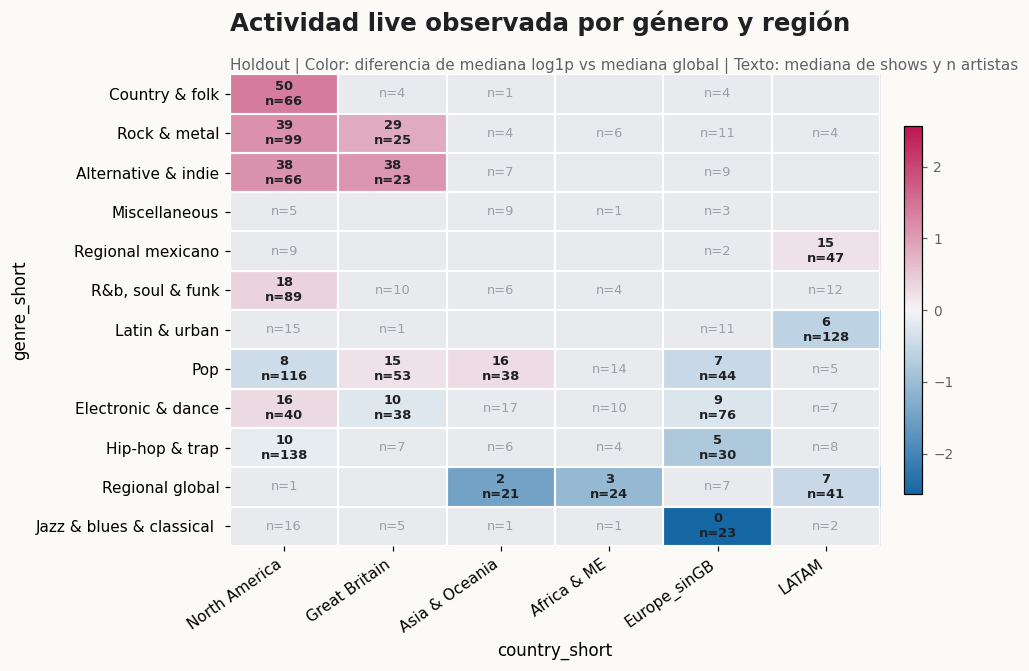

Guardado en: graficos_lgbm-regression\lgbm-regression_heatmap_genero_region_actividad_observada.png


In [61]:
# ============================================================
# Heatmap de actividad live observada
# Género musical × región geográfica
# ============================================================

graficar_heatmap_cruce_categorico(
    tabla_cruce=tabla_genero_region,
    variable_fila="genre_short",
    variable_columna="country_short",
    columna_color="dif_log_mediana_vs_global_plot",
    tipo_anotacion="shows",
    titulo_grafico="Actividad live observada por género y región",
    subtitulo_grafico=(
        "Holdout | Color: diferencia de mediana log1p vs mediana global | "
        "Texto: mediana de shows y n artistas"
    ),
    nombre_archivo=f"{PARAM['experimento']}_heatmap_genero_region_actividad_observada.png",
    n_minimo_celda=n_minimo_celda
)



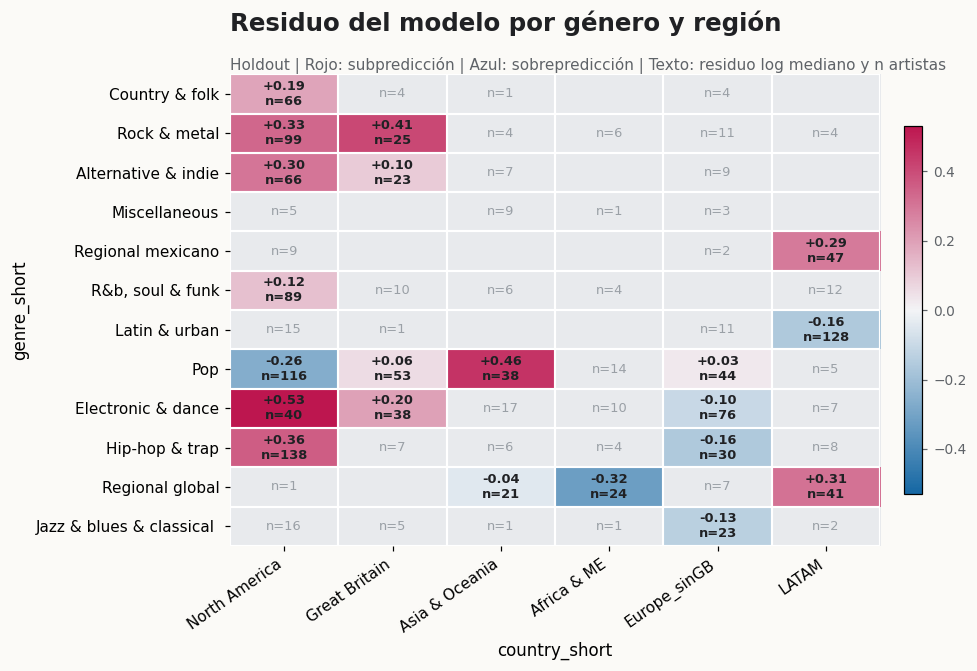

Guardado en: graficos_lgbm-regression\lgbm-regression_heatmap_genero_region_residuo_modelo.png


In [62]:
# ============================================================
# Heatmap de residuo mediano del modelo
# Género musical × región geográfica
# ============================================================

graficar_heatmap_cruce_categorico(
    tabla_cruce=tabla_genero_region,
    variable_fila="genre_short",
    variable_columna="country_short",
    columna_color="residuo_log_mediano_plot",
    tipo_anotacion="residuo",
    titulo_grafico="Residuo del modelo por género y región",
    subtitulo_grafico=(
        "Holdout | Rojo: subpredicción | Azul: sobrepredicción | "
        "Texto: residuo log mediano y n artistas"
    ),
    nombre_archivo=f"{PARAM['experimento']}_heatmap_genero_region_residuo_modelo.png",
    n_minimo_celda=n_minimo_celda
)

In [63]:
# ============================================================
# Cruces prioritarios adicionales
# ============================================================

pares_categoricos_prioritarios = [
    ("genre_short", "major_record_label"),
    ("genre_short", "band")
]

tablas_cruces_prioritarios = {
    "genre_short__country_short": tabla_genero_region
}

for variable_fila, variable_columna in pares_categoricos_prioritarios:
    
    nombre_cruce = f"{variable_fila}__{variable_columna}"
    
    tabla_cruce_actual = construir_tabla_cruce_categorico(
        df_base=df_perfilamiento_categorico,
        variable_fila=variable_fila,
        variable_columna=variable_columna,
        n_minimo_celda=n_minimo_celda
    )
    
    tablas_cruces_prioritarios[nombre_cruce] = tabla_cruce_actual
    
    print(f"\nCruce {variable_fila} × {variable_columna}")
    display(tabla_cruce_actual)
    
    tabla_cruce_actual.to_csv(
        f"{PARAM['experimento']}_cruce_{variable_fila}_{variable_columna}_holdout.csv",
        index=False
    )


Cruce genre_short × major_record_label


,genre_short,major_record_label,n_artistas,shows_obs_mediana,shows_pred_mediana,y_obs_log_mediana,y_pred_log_mediana,residuo_log_mediano,brecha_original_mediana,dif_log_mediana_vs_global,dif_shows_mediana_vs_global,celda_robusta,lectura_residuo,shows_obs_mediana_plot,dif_log_mediana_vs_global_plot,residuo_log_mediano_plot
0,Country & folk,1.0,20,71.5,44.072069,4.282420,3.808105,0.195784,10.393990,1.717471,5.950000e+01,True,subpredicción,71.5,1.717471,0.195784
1,Country & folk,0.0,49,44.0,25.654564,3.806662,3.282960,0.199557,11.039682,1.241713,3.200000e+01,True,subpredicción,44.0,1.241713,0.199557
2,Alternative & indie,1.0,25,40.0,18.292142,3.713572,2.959698,0.470877,13.120195,1.148623,2.800000e+01,True,subpredicción,40.0,1.148623,0.470877
3,Alternative & indie,0.0,76,37.5,24.419635,3.650574,3.235491,0.284948,6.396502,1.085625,2.550000e+01,True,subpredicción,37.5,1.085625,0.284948
4,Rock & metal,1.0,30,36.0,17.913018,3.605040,2.939424,0.505331,16.540474,1.040090,2.400000e+01,True,subpredicción,36.0,1.040090,0.505331
5,Rock & metal,0.0,112,34.5,14.320050,3.569433,2.729113,0.407258,12.404244,1.004484,2.250000e+01,True,subpredicción,34.5,1.004484,0.407258
6,"R&b, soul & funk",1.0,36,30.0,16.537377,3.433987,2.864271,0.290306,7.935696,0.869038,1.800000e+01,True,subpredicción,30.0,0.869038,0.290306
7,Pop,1.0,91,23.0,14.559255,3.178054,2.744656,0.377045,6.462652,0.613104,1.100000e+01,True,subpredicción,23.0,0.613104,0.377045
8,Regional mexicano,0.0,40,16.5,14.020096,2.861793,2.709325,0.387739,5.739536,0.296843,4.500000e+00,True,subpredicción,16.5,0.296843,0.387739
9,Electronic & dance,0.0,143,12.0,9.210401,2.564949,2.323407,0.206667,2.158633,0.000000,0.000000e+00,True,subpredicción,12.0,0.000000,0.206667



Cruce genre_short × band


,genre_short,band,n_artistas,shows_obs_mediana,shows_pred_mediana,y_obs_log_mediana,y_pred_log_mediana,residuo_log_mediano,brecha_original_mediana,dif_log_mediana_vs_global,dif_shows_mediana_vs_global,celda_robusta,lectura_residuo,shows_obs_mediana_plot,dif_log_mediana_vs_global_plot,residuo_log_mediano_plot
0,Country & folk,0.0,54,57.5,34.609155,4.068113,3.572105,0.215778,10.807985,1.503163,45.5,True,subpredicción,57.5,1.503163,0.215778
1,Rock & metal,1.0,98,45.0,18.911480,3.828405,2.991281,0.407258,15.974071,1.263456,33.0,True,subpredicción,45.0,1.263456,0.407258
2,Alternative & indie,1.0,65,38.0,21.187711,3.663562,3.099539,0.267085,9.676342,1.098612,26.0,True,subpredicción,38.0,1.098612,0.267085
3,Alternative & indie,0.0,40,31.0,18.198275,3.463779,2.954808,0.365732,7.458655,0.898830,19.0,True,subpredicción,31.0,0.898830,0.365732
4,Country & folk,1.0,21,25.0,19.960318,3.258097,3.042631,0.045813,3.627162,0.693147,13.0,True,subpredicción,25.0,0.693147,0.045813
5,Regional mexicano,1.0,34,22.5,14.020096,3.145785,2.709325,0.533439,7.223171,0.580835,10.5,True,subpredicción,22.5,0.580835,0.533439
6,Latin & urban,1.0,41,21.0,9.705218,3.091042,2.370731,0.390348,5.866778,0.526093,9.0,True,subpredicción,21.0,0.526093,0.390348
7,Regional mexicano,0.0,24,15.0,15.882079,2.770632,2.824713,-0.035889,0.504504,0.205682,3.0,True,sobrepredicción,15.0,0.205682,-0.035889
8,"R&b, soul & funk",0.0,100,14.5,13.251768,2.740319,2.656877,0.078754,0.728218,0.175370,2.5,True,subpredicción,14.5,0.175370,0.078754
9,Pop,0.0,190,11.0,8.816004,2.484907,2.284010,0.020070,0.210927,-0.080043,-1.0,True,subpredicción,11.0,-0.080043,0.020070
